# SIBGRAPI 2026 — Beyond Watertight Geometry: Neural Unsigned Distance Fields

**Companion notebook for Block 1.** Everything here runs on **CPU** in a few minutes.

This notebook is split into **LAB blocks**. Each LAB is the hands-on counterpart of one
block of slides: the slide deck announces the LAB on a *"Now to the notebook"* slide, and
the LAB ends with a pointer back to the slide we resume from.

| LAB | Topic | Comes from slides | Announced on | Back to slide |
|:--|:--|:--|:--|:--|
| **LAB 0** | Setup — run this first | — | — | — |
| **LAB 1** | Analytic SDF and UDF | 10–21 | 22 | 23 |
| **LAB 2** | Gradients of the exact UDF | 23–25 | 26 | 27 |
| **LAB 3** | Your first neural field | 31–36 | 37 | 38 |
| **LAB 4** | Sampling from point clouds | 38–44 | 45 | 46 |
| **LAB 5** | Spatial gradients of a trained net | 46–52 | 53 | 54 |
| **LAB 6** | Gradient-based projection | 54–59 | 60 | 61 |
| **LAB 7** | ReLU vs. SIREN | 61–67 | 68 | 69 |
| **LAB 8** | Marching Cubes: SDF vs. UDF | 69–73 | 74 | 75 |
| **LAB 9** | Where the CPU time goes | 75–80 | 81 | 82 |
| **LAB 10** | End-to-end Neural UDF in 3D | 82–89 | 90 | 91 |
| **BONUS** | A real scan: the Stanford Bunny (not in the talk) | — | — | — |

Slide numbers refer to `main.pdf` (93 slides). `FAST_MODE = True` keeps every LAB short
enough to run live; set it to `False` for nicer figures.

---

# LAB 0 — Setup

> **Run this before the talk starts.** It only imports, seeds and pins the thread count.

Everything is CPU-only: `torch`, `numpy`, `matplotlib`, `scipy` and `scikit-image`.
LAB 10 also uses `plotly` for an interactive 3D view (`pip install plotly nbformat`).


In [115]:
import math
import time
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.spatial import cKDTree
from skimage import measure

SEED = 7
FAST_MODE = True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
torch.set_num_threads(max(1, min(4, torch.get_num_threads())))

print("PyTorch:", torch.__version__)
print("Device:", device)
print("Threads:", torch.get_num_threads())


PyTorch: 2.14.0+cpu
Device: cpu
Threads: 4


---

# LAB 1 — Analytic SDF and UDF

> **⟵ Coming from slides 10–21** &nbsp;·&nbsp; *"Implicit geometry = level set of a field" → "UDFs: what we gain and what we lose"*  
> **Hand-off slide:** 22 — *"Now to the notebook"*

**Why we are here.** The slides defined a surface as the level set of a scalar field, and
then removed the sign to obtain the UDF. Here we look at both fields for a shape we know
exactly, so that every later plot has a reference to be compared against.


## 1.1 Analytic SDF: a circle in 2D

For a circle of radius $r$ centred at the origin:

$$s(x,y)=\sqrt{x^2+y^2}-r.$$

- $s<0$: inside;
- $s=0$: the surface;
- $s>0$: outside.

The surface is the **zero level set** — exactly the definition on slide 10.


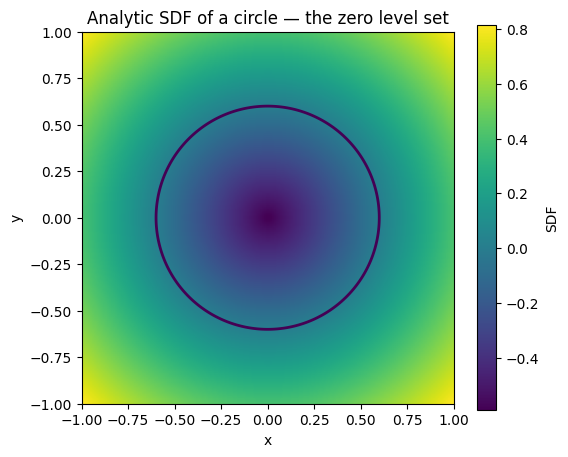

In [116]:
def sdf_circle_xy(xy, radius=0.6):
    return torch.linalg.norm(xy, dim=-1, keepdim=True) - radius

R = 180
lin = torch.linspace(-1.0, 1.0, R)
yy, xx = torch.meshgrid(lin, lin, indexing="ij")
grid2 = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=-1)

with torch.inference_mode():
    sdf_vals = sdf_circle_xy(grid2).reshape(R, R).numpy()

plt.figure(figsize=(6, 5))
plt.imshow(sdf_vals, extent=[-1, 1, -1, 1], origin="lower")
plt.colorbar(label="SDF")
plt.contour(xx.numpy(), yy.numpy(), sdf_vals, levels=[0.0], linewidths=2)
plt.title("Analytic SDF of a circle — the zero level set")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## 1.2 Analytic UDF: dropping the sign

The matching UDF is simply

$$u(x,y)=|s(x,y)|.$$

It keeps the distance to the surface and discards inside/outside. Note that the zero level
set is now a *minimum* of the field rather than a crossing — that is the whole difficulty
the slides build on.


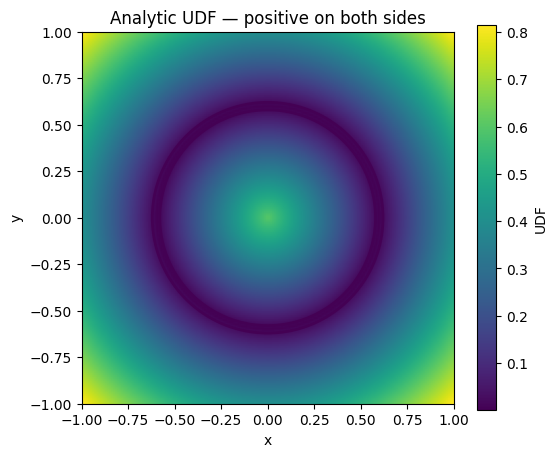

In [117]:
with torch.inference_mode():
    udf_vals = sdf_circle_xy(grid2).abs().reshape(R, R).numpy()

plt.figure(figsize=(6, 5))
plt.imshow(udf_vals, extent=[-1, 1, -1, 1], origin="lower")
plt.colorbar(label="UDF")
plt.contour(xx.numpy(), yy.numpy(), udf_vals, levels=[0.02], linewidths=2)
plt.title("Analytic UDF — positive on both sides")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## 1.3 The local profile $|t|$

Near a smooth surface point, along the normal coordinate $t$:

$$s(t)\approx t, \qquad u(t)\approx|t|.$$

The derivative jumps from $-1$ to $+1$ across the surface, so at $t=0$ there is no
classical derivative. This is the cusp shown on slides 19–21.


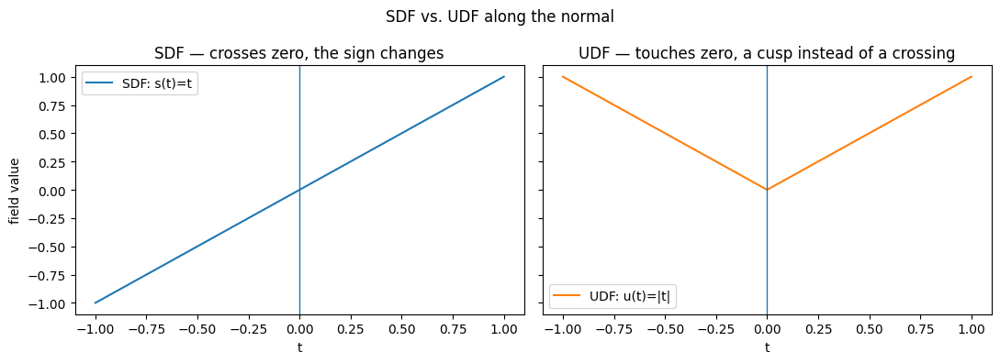

In [118]:
t = torch.linspace(-1, 1, 401)
s = t
u = t.abs()

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

ax[0].plot(t.numpy(), s.numpy(), label="SDF: s(t)=t")
ax[0].axvline(0.0, linewidth=1)
ax[0].set_title("SDF — crosses zero, the sign changes")
ax[0].set_xlabel("t")
ax[0].set_ylabel("field value")
ax[0].legend(loc="upper left")

ax[1].plot(t.numpy(), u.numpy(), label="UDF: u(t)=|t|", color="tab:orange")
ax[1].axvline(0.0, linewidth=1)
ax[1].set_title("UDF — touches zero, a cusp instead of a crossing")
ax[1].set_xlabel("t")
ax[1].legend(loc="lower left")

fig.suptitle("SDF vs. UDF along the normal")
plt.tight_layout()
plt.show()


> **↪ Back to the slides — slide 23:** *"The problem originates in the UDF itself"*  
> **Next notebook stop:** LAB 2 — Gradients of the exact UDF (announced on slide 26)

---


---

# LAB 2 — Gradients of the exact UDF

> **⟵ Coming from slides 23–25** &nbsp;·&nbsp; *"The problem originates in the UDF itself" → "Why does the gradient near the surface matter?"*  
> **Hand-off slide:** 26 — *"Now to the notebook"*

**Why we are here.** The slides argued that the trouble starts in the *exact* UDF, before
any network is involved. We check that claim numerically: the gradient has unit norm away
from the surface, and its direction flips when we cross the zero level set.


points:
tensor([[0.2000, 0.0000],
        [0.8000, 0.0000],
        [0.0000, 0.9000]])

UDF:
tensor([[0.4000],
        [0.2000],
        [0.3000]])

spatial gradients:
tensor([[-1., -0.],
        [ 1.,  0.],
        [ 0.,  1.]])

norms:
tensor([1., 1., 1.])


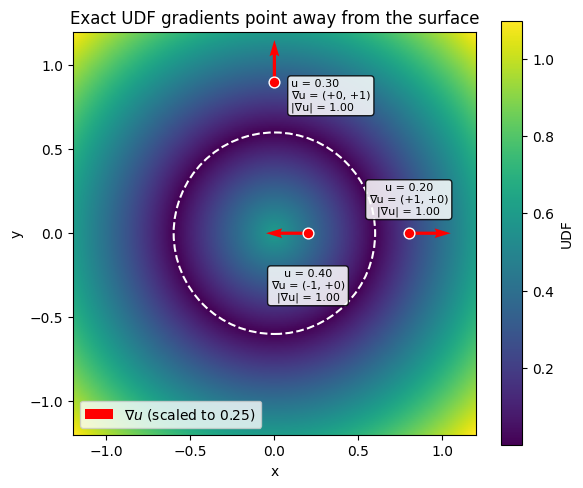

In [119]:
def analytic_udf_torch(xy, radius=0.6):
    return (torch.linalg.norm(xy, dim=-1, keepdim=True) - radius).abs()

probe = torch.tensor([
    [0.2, 0.0],   # inside
    [0.8, 0.0],   # outside
    [0.0, 0.9],   # outside
], dtype=torch.float32, requires_grad=True)

d = analytic_udf_torch(probe)
g = torch.autograd.grad(
    outputs=d,
    inputs=probe,
    grad_outputs=torch.ones_like(d),
    create_graph=False
)[0]

print("points:")
print(probe.detach())
print("\nUDF:")
print(d.detach())
print("\nspatial gradients:")
print(g.detach())
print("\nnorms:")
print(g.norm(dim=-1).detach())

# Plot the probes on top of the UDF, with their gradients as arrows.
Rp = 200
lin_p = torch.linspace(-1.2, 1.2, Rp)
yy_p, xx_p = torch.meshgrid(lin_p, lin_p, indexing="ij")
with torch.inference_mode():
    u_grid = analytic_udf_torch(torch.stack([xx_p, yy_p], dim=-1)).squeeze(-1).numpy()

P = probe.detach().numpy()
G = g.detach().numpy() + 0.0  # + 0.0 turns -0 into 0 for printing
D = d.detach().squeeze(-1).numpy()
N = g.norm(dim=-1).detach().numpy()

plt.figure(figsize=(6.5, 5.5))
plt.imshow(u_grid, extent=[-1.2, 1.2, -1.2, 1.2], origin="lower")
plt.colorbar(label="UDF")
plt.gca().add_patch(plt.Circle((0, 0), 0.6, fill=False, color="white", linestyle="--", linewidth=1.5))
plt.quiver(P[:, 0], P[:, 1], G[:, 0], G[:, 1], angles="xy", scale_units="xy", scale=4,
           color="red", width=0.008, label=r"$\nabla u$ (scaled to 0.25)")
plt.scatter(P[:, 0], P[:, 1], color="red", edgecolor="white", s=60, zorder=3)
label_offsets = [(0, -48), (0, 14), (12, -20)]  # below / above / right of each probe
for (px, py), (gx, gy), dv, nv, off in zip(P, G, D, N, label_offsets):
    plt.annotate(f"u = {dv:.2f}\n∇u = ({gx:+.0f}, {gy:+.0f})\n|∇u| = {nv:.2f}",
                 (px, py), xytext=off, textcoords="offset points", fontsize=8,
                 ha="left" if off[0] > 0 else "center",
                 bbox=dict(boxstyle="round", fc="white", alpha=0.85))
plt.title("Exact UDF gradients point away from the surface")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="lower left")
plt.gca().set_aspect("equal")
plt.show()


UDF: tensor([0.0500, 0.0500])
spatial gradients:
tensor([[-1., -0.],
        [ 1.,  0.]])


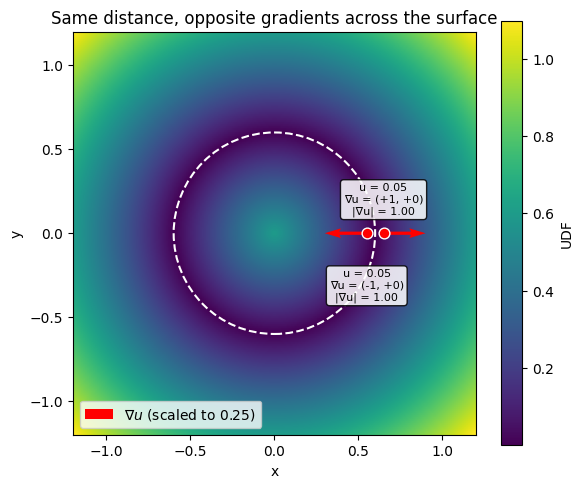

In [120]:
# Two probes on either side of the surface, both at distance 0.05 from it.
pair = torch.tensor([
    [0.55, 0.0],   # just inside
    [0.65, 0.0],   # just outside
], dtype=torch.float32, requires_grad=True)

d_pair = analytic_udf_torch(pair)
g_pair = torch.autograd.grad(d_pair, pair, grad_outputs=torch.ones_like(d_pair))[0]

print("UDF:", d_pair.detach().squeeze(-1))
print("spatial gradients:")
print(g_pair.detach())

P = pair.detach().numpy()
G = g_pair.detach().numpy() + 0.0  # + 0.0 turns -0 into 0 for printing
D = d_pair.detach().squeeze(-1).numpy()
N = g_pair.norm(dim=-1).detach().numpy()

plt.figure(figsize=(6.5, 5.5))
plt.imshow(u_grid, extent=[-1.2, 1.2, -1.2, 1.2], origin="lower")
plt.colorbar(label="UDF")
plt.gca().add_patch(plt.Circle((0, 0), 0.6, fill=False, color="white", linestyle="--", linewidth=1.5))
plt.quiver(P[:, 0], P[:, 1], G[:, 0], G[:, 1], angles="xy", scale_units="xy", scale=4,
           color="red", width=0.008, label=r"$\nabla u$ (scaled to 0.25)")
plt.scatter(P[:, 0], P[:, 1], color="red", edgecolor="white", s=60, zorder=3)
label_offsets = [(0, -48), (0, 14)]  # below / above each probe
for (px, py), (gx, gy), dv, nv, off in zip(P, G, D, N, label_offsets):
    plt.annotate(f"u = {dv:.2f}\n∇u = ({gx:+.0f}, {gy:+.0f})\n|∇u| = {nv:.2f}",
                 (px, py), xytext=off, textcoords="offset points", fontsize=8, ha="center",
                 bbox=dict(boxstyle="round", fc="white", alpha=0.85))
plt.title("Same distance, opposite gradients across the surface")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="lower left")
plt.gca().set_aspect("equal")
plt.show()

### The sign flip, seen along a line

We walk along the $x$ axis, straight through the circle, and read off
$\partial u/\partial x$. Away from the surface the magnitude is $1$; the *sign* is what
carries the geometry, and it is exactly what reverses at the cusp.


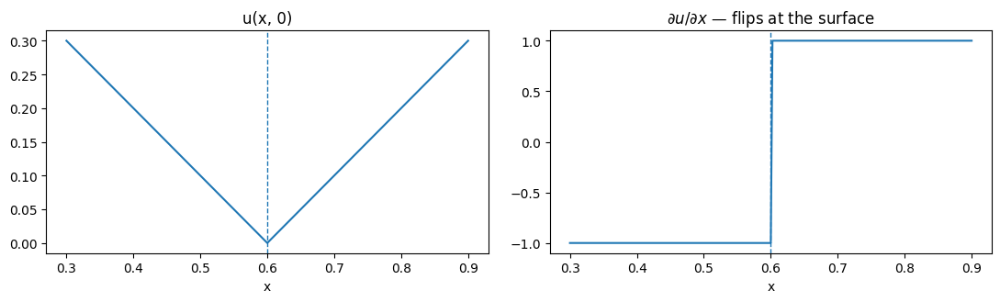

|grad| just inside : 1.0
|grad| just outside: 1.0


In [121]:
line_x = torch.linspace(0.30, 0.90, 241).reshape(-1, 1)
line = torch.cat([line_x, torch.zeros_like(line_x)], dim=-1).requires_grad_(True)

vals = analytic_udf_torch(line)
gl = torch.autograd.grad(vals, line, grad_outputs=torch.ones_like(vals))[0]

x_np = line[:, 0].detach().numpy()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(x_np, vals.detach().numpy())
ax[0].axvline(0.6, linestyle="--", linewidth=1)
ax[0].set_title("u(x, 0)")
ax[0].set_xlabel("x")
ax[1].plot(x_np, gl[:, 0].detach().numpy())
ax[1].axvline(0.6, linestyle="--", linewidth=1)
ax[1].set_title(r"$\partial u/\partial x$ — flips at the surface")
ax[1].set_xlabel("x")
plt.tight_layout()
plt.show()

print("|grad| just inside :", gl[:, 0].detach()[x_np < 0.59].abs().mean().item())
print("|grad| just outside:", gl[:, 0].detach()[x_np > 0.61].abs().mean().item())


> **↪ Back to the slides — slide 27:** *"Two later answers to the problem"*  
> **Next notebook stop:** LAB 3 — Your first neural field (announced on slide 37)

---


---

# LAB 3 — Your first neural field

> **⟵ Coming from slides 31–36** &nbsp;·&nbsp; *"From the geometric UDF to a neural UDF" → "One training iteration"*  
> **Hand-off slide:** 37 — *"Now to the notebook"*

**Why we are here.** Slides 31–36 turned the UDF into a supervised regression problem:
sample coordinates, ask for distances, minimise L1. We now replace the analytic field by a
coordinate MLP and watch the zero level set appear from distance supervision alone.


## 3.1 Neural **SDF** first

$$(x,y)\mapsto f_\theta(x,y)\approx s(x,y).$$

The signed case is the easy one, and it gives us a sanity check before removing the sign.


Neural SDF training: 0.44s | final loss=0.00412


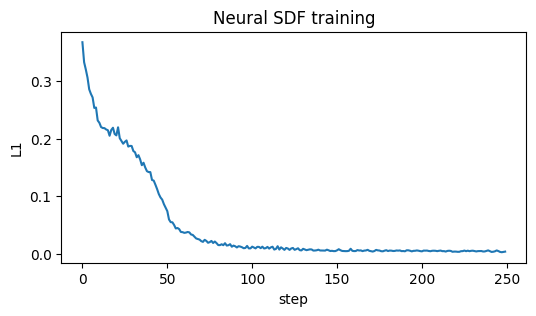

In [122]:
class TinyMLP(nn.Module):
    def __init__(self, in_dim, hidden=64, out_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)

def sample_square(n, dim=2):
    return 2.0 * torch.rand(n, dim) - 1.0

sdf_net = TinyMLP(2, hidden=64).to(device)
opt = torch.optim.Adam(sdf_net.parameters(), lr=1e-3)

steps = 250 if FAST_MODE else 800
batch_size = 1024

history_sdf = []
t0 = time.time()

for step in range(steps):
    xy = sample_square(batch_size, 2).to(device)
    target = sdf_circle_xy(xy)

    pred = sdf_net(xy)
    loss = F.l1_loss(pred, target)

    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()

    history_sdf.append(loss.item())

print(f"Neural SDF training: {time.time()-t0:.2f}s | final loss={history_sdf[-1]:.5f}")

plt.figure(figsize=(6, 3))
plt.plot(history_sdf)
plt.xlabel("step")
plt.ylabel("L1")
plt.title("Neural SDF training")
plt.show()


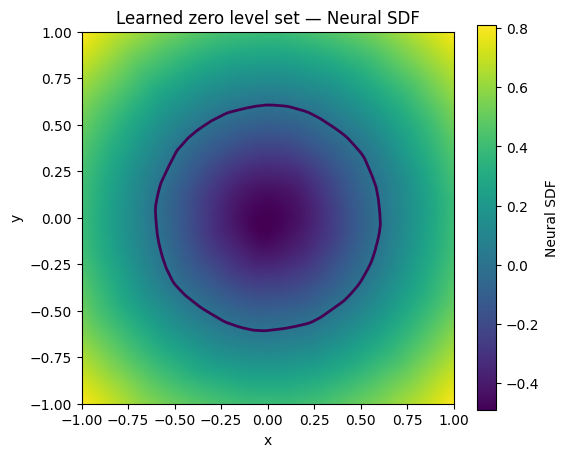

In [123]:
with torch.inference_mode():
    pred_sdf = sdf_net(grid2).reshape(R, R).numpy()

plt.figure(figsize=(6, 5))
plt.imshow(pred_sdf, extent=[-1, 1, -1, 1], origin="lower")
plt.colorbar(label="Neural SDF")
plt.contour(xx.numpy(), yy.numpy(), pred_sdf, levels=[0.0], linewidths=2)
plt.title("Learned zero level set — Neural SDF")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## 3.2 The same network, unsigned targets

Now the targets are non-negative, $d_i=u(x_i)$. Nothing else changes: the loss still only
sees **distances**. Connectivity, normals and gradients are never supervised — the point
made on slide 32.

Note the output layer is still **linear**, exactly like the didactic baseline on slide 31:
it is a distance *surrogate* and can go slightly negative.


final loss: 0.00846562348306179


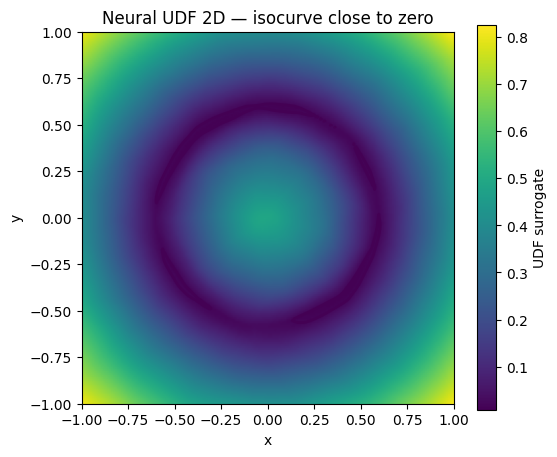

In [124]:
udf_net_2d = TinyMLP(2, hidden=64).to(device)
opt = torch.optim.Adam(udf_net_2d.parameters(), lr=1e-3)

steps = 300 if FAST_MODE else 900
history_udf2 = []

for step in range(steps):
    xy = sample_square(1024, 2)
    target = analytic_udf_torch(xy)

    pred = udf_net_2d(xy)
    loss = F.l1_loss(pred, target)

    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()

    history_udf2.append(loss.item())

print("final loss:", history_udf2[-1])

with torch.inference_mode():
    pred_udf2 = udf_net_2d(grid2).reshape(R, R).numpy()

plt.figure(figsize=(6, 5))
plt.imshow(pred_udf2, extent=[-1, 1, -1, 1], origin="lower")
plt.colorbar(label="UDF surrogate")
plt.contour(xx.numpy(), yy.numpy(), pred_udf2, levels=[0.02], linewidths=2)
plt.title("Neural UDF 2D — isocurve close to zero")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## 3.3 Network gradients near the surface

Both networks now fit their distances. We probe them on two rings at distance $0.08$ from
the circle, one inside and one outside, and draw $\nabla_x f_\theta$ at each probe. The
arrows are **not** normalised, so arrow length is the gradient norm.

- **Neural SDF:** the gradient points outward on *both* sides. It is the normal, and it
  varies smoothly across the surface.
- **Neural UDF:** the gradient points *away* from the surface on each side, so it flips
  direction across it, exactly like the analytic UDF of LAB 2.

At this distance both norms are still close to $1$. The price of the flip is paid closer
in: a smooth network cannot reverse its gradient instantly, so within a few hundredths of
the surface the UDF gradient shrinks towards zero. LAB 5 measures this.

Neural SDF:
  inside (r = 0.52)    mean |grad| = 0.97   mean radial component = +0.96
  outside (r = 0.68)   mean |grad| = 1.00   mean radial component = +0.99
Neural UDF:
  inside (r = 0.52)    mean |grad| = 1.12   mean radial component = -1.11
  outside (r = 0.68)   mean |grad| = 0.95   mean radial component = +0.94


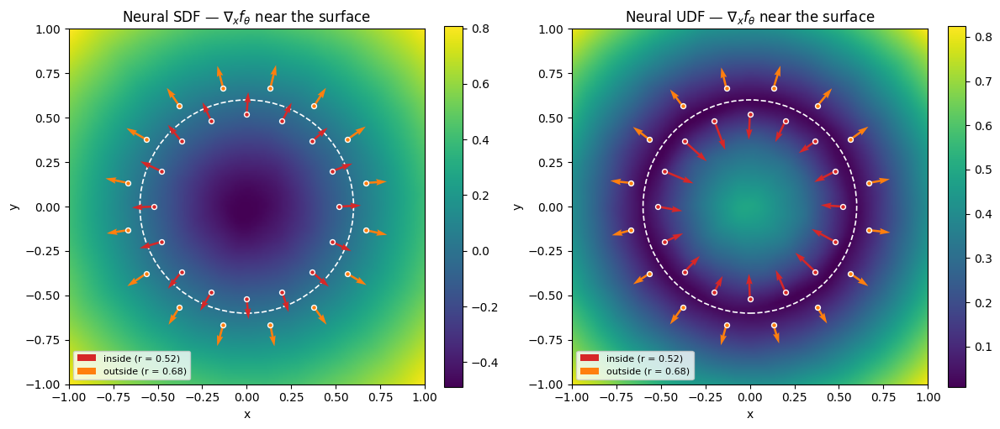

In [125]:
def input_gradient(net, x):
    x = x.detach().clone().requires_grad_(True)
    y = net(x)
    return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y))[0].detach()

n_ring = 16
ang = torch.linspace(0, 2 * math.pi, n_ring + 1)[:-1]
ring_in = 0.52 * torch.stack([torch.cos(ang), torch.sin(ang)], dim=-1)            # u = 0.08 inside
ang_out = ang + math.pi / n_ring                                                   # staggered, so arrows do not overlap
ring_out = 0.68 * torch.stack([torch.cos(ang_out), torch.sin(ang_out)], dim=-1)   # u = 0.08 outside
rings = {"inside (r = 0.52)": ring_in, "outside (r = 0.68)": ring_out}

panels = [
    ("Neural SDF", sdf_net, pred_sdf),
    ("Neural UDF", udf_net_2d, pred_udf2),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, (name, net, field) in zip(axes, panels):
    im = ax.imshow(field, extent=[-1, 1, -1, 1], origin="lower")
    fig.colorbar(im, ax=ax, fraction=0.046)
    ax.add_patch(plt.Circle((0, 0), 0.6, fill=False, color="white", linestyle="--", linewidth=1.2))
    print(f"{name}:")
    for (label, pts), color in zip(rings.items(), ["tab:red", "tab:orange"]):
        grad = input_gradient(net, pts)
        radial = (grad * pts / pts.norm(dim=-1, keepdim=True)).sum(dim=-1)  # > 0 means pointing outward
        P, G = pts.numpy(), grad.numpy()
        ax.quiver(P[:, 0], P[:, 1], G[:, 0], G[:, 1], angles="xy", scale_units="xy", scale=8,
                  color=color, width=0.006, label=label)
        ax.scatter(P[:, 0], P[:, 1], color=color, edgecolor="white", s=18, zorder=3)
        print(f"  {label:<20} mean |grad| = {grad.norm(dim=-1).mean():.2f}   "
              f"mean radial component = {radial.mean():+.2f}")
    ax.set_title(rf"{name} — $\nabla_x f_\theta$ near the surface")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()

## 3.4 When the gradient points the wrong way

The loss in 3.2 only compares values, $f_\theta(x_i)$ against $d_i$. The gradient is
**never supervised**. The network matches the distances to about $0.01$, but nothing forces
the bottom of its valley to sit exactly on the surface, and nothing forces its value there
to be $0$.

Wherever the valley drifts off the surface, the points between the valley and the true
surface get a gradient that points **towards** the surface instead of away from it: the
direction is reversed. The descent direction $-\nabla_x f_\theta$ then pushes those points
away from the surface and into the network's valley. This is the failure the projection
of LAB 6 inherits.

- **Left:** cosine between the network gradient and the exact gradient (blue = same
  direction, red = reversed). The white speckle at the centre is not this effect: the exact
  UDF has a peak there, where its own gradient is undefined.
- **Right:** a zoom on the stretch of circle with the most reversed arrows. Arrows are
  normalised, so only direction is shown.

fraction of points whose network gradient points the wrong way (cos < 0):
  u in [0.00, 0.01)   inside: 0.66   outside: 0.11
  u in [0.01, 0.02)   inside: 0.42   outside: 0.00
  u in [0.02, 0.03)   inside: 0.15   outside: 0.00
  u in [0.03, 0.05)   inside: 0.01   outside: 0.00
  u in [0.05, 1.00)   inside: 0.00   outside: 0.00

radius of the network's minimum along 72 rays: mean 0.589, range [0.566, 0.614]  (true surface: 0.600)
network value at its minimum: mean 0.016  (true: 0)


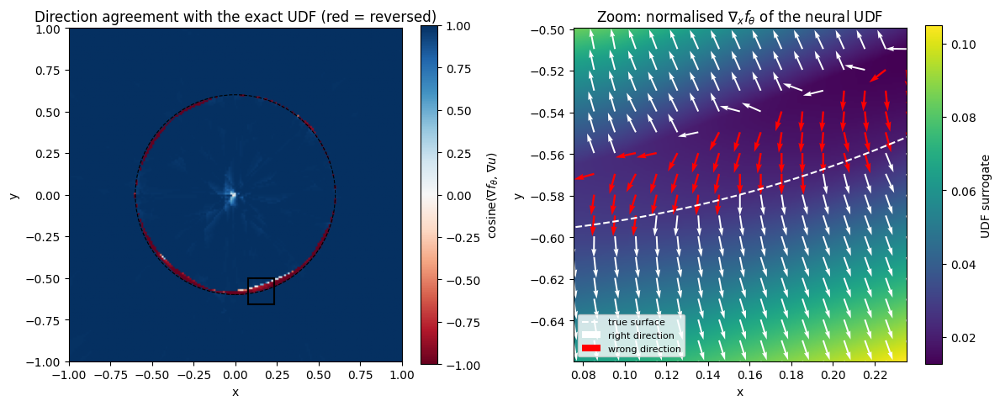

In [126]:
def true_udf_gradient(x):
    x = x.detach().clone().requires_grad_(True)
    y = analytic_udf_torch(x)
    return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y))[0].detach()

# Compare the network's gradient with the exact one on the full grid.
g_net = input_gradient(udf_net_2d, grid2)
g_true = true_udf_gradient(grid2)
cos_sim = F.cosine_similarity(g_net, g_true, dim=-1)       # +1: right direction, -1: reversed
dist_true = analytic_udf_torch(grid2).squeeze(-1)
inside = grid2.norm(dim=-1) < 0.6

print("fraction of points whose network gradient points the wrong way (cos < 0):")
for lo, hi in [(0.0, 0.01), (0.01, 0.02), (0.02, 0.03), (0.03, 0.05), (0.05, 1.0)]:
    band = (dist_true >= lo) & (dist_true < hi)
    print(f"  u in [{lo:.2f}, {hi:.2f})   inside: {(cos_sim[band & inside] < 0).float().mean():.2f}"
          f"   outside: {(cos_sim[band & ~inside] < 0).float().mean():.2f}")

# Where along each ray does the network put the bottom of its valley?
radii = torch.linspace(0.45, 0.75, 601)
rays = torch.linspace(0, 2 * math.pi, 73)[:-1]
ray_pts = radii[None, :, None] * torch.stack([torch.cos(rays), torch.sin(rays)], dim=-1)[:, None, :]
with torch.inference_mode():
    ray_vals = udf_net_2d(ray_pts.reshape(-1, 2)).reshape(len(rays), len(radii))
r_min = radii[ray_vals.argmin(dim=1)]
print(f"\nradius of the network's minimum along 72 rays: mean {r_min.mean():.3f}, "
      f"range [{r_min.min():.3f}, {r_min.max():.3f}]  (true surface: 0.600)")
print(f"network value at its minimum: mean {ray_vals.min(dim=1).values.mean():.3f}  (true: 0)")

# Zoom on the stretch of the circle with the most reversed gradients.
wrong = (cos_sim < 0) & (dist_true < 0.05)
wrong_ang = torch.atan2(grid2[wrong, 1], grid2[wrong, 0])
counts = torch.histc(wrong_ang, bins=36, min=-math.pi, max=math.pi)
a0 = -math.pi + (counts.argmax().item() + 0.5) * (2 * math.pi / 36)
cx, cy, half = 0.6 * math.cos(a0), 0.6 * math.sin(a0), 0.08

zg = torch.linspace(-half, half, 17)
zy, zx = torch.meshgrid(zg, zg, indexing="ij")
zoom = torch.stack([cx + zx.reshape(-1), cy + zy.reshape(-1)], dim=-1)
gz = input_gradient(udf_net_2d, zoom)
ok = F.cosine_similarity(gz, true_udf_gradient(zoom), dim=-1) >= 0
gz_dir = (gz / (gz.norm(dim=-1, keepdim=True) + 1e-8)).numpy()   # direction only
Z = zoom.numpy()

zr = torch.linspace(-half, half, 200)
zry, zrx = torch.meshgrid(zr, zr, indexing="ij")
with torch.inference_mode():
    zoom_field = udf_net_2d(torch.stack([cx + zrx.reshape(-1), cy + zry.reshape(-1)], dim=-1)).reshape(200, 200).numpy()
zoom_extent = [cx - half, cx + half, cy - half, cy + half]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

im = axes[0].imshow(cos_sim.reshape(R, R).numpy(), extent=[-1, 1, -1, 1], origin="lower",
                    cmap="RdBu", vmin=-1, vmax=1)
fig.colorbar(im, ax=axes[0], fraction=0.046, label=r"cosine($\nabla f_\theta$, $\nabla u$)")
axes[0].add_patch(plt.Circle((0, 0), 0.6, fill=False, color="black", linestyle="--", linewidth=0.8))
axes[0].add_patch(plt.Rectangle((cx - half, cy - half), 2 * half, 2 * half, fill=False, color="black", linewidth=1.5))
axes[0].set_title("Direction agreement with the exact UDF (red = reversed)")

im = axes[1].imshow(zoom_field, extent=zoom_extent, origin="lower")
fig.colorbar(im, ax=axes[1], fraction=0.046, label="UDF surrogate")
circ = torch.linspace(0, 2 * math.pi, 2000)
axes[1].plot(0.6 * torch.cos(circ), 0.6 * torch.sin(circ), "w--", linewidth=1.5, label="true surface")
axes[1].quiver(Z[ok, 0], Z[ok, 1], gz_dir[ok, 0], gz_dir[ok, 1], color="white",
               angles="xy", scale_units="xy", scale=100, width=0.005, label="right direction")
axes[1].quiver(Z[~ok, 0], Z[~ok, 1], gz_dir[~ok, 0], gz_dir[~ok, 1], color="red",
               angles="xy", scale_units="xy", scale=100, width=0.006, label="wrong direction")
axes[1].set_xlim(zoom_extent[:2])
axes[1].set_ylim(zoom_extent[2:])
axes[1].set_title(r"Zoom: normalised $\nabla_x f_\theta$ of the neural UDF")
axes[1].legend(loc="lower left", fontsize=8)

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

> **↪ Back to the slides — slide 38:** *"Where do the pairs $(x_i,d_i)$ come from?"*  
> **Next notebook stop:** LAB 4 — Sampling from point clouds (announced on slide 45)

---


---

# LAB 4 — Sampling from point clouds

> **⟵ Coming from slides 38–44** &nbsp;·&nbsp; *"Where do the pairs $(x_i,d_i)$ come from?" → "Didactic dataset generation pipeline"*  
> **Hand-off slide:** 45 — *"Now to the notebook"*

**Why we are here.** So far the targets came from a formula. Slides 38–44 described where
they come from in practice: a point cloud, three sampling regimes and nearest-point
distances. We also switch to an **open** curve — a shape with no meaningful inside.


## 4.1 Surface + near-surface + uniform

$$d_i=\min_{p_j\in P}\lVert x_i-p_j\rVert_2.$$

This is the point-set approximation of slide 42, not the ground-truth surface UDF the
original NDF regresses. The three regimes are the ones on slides 39–41.


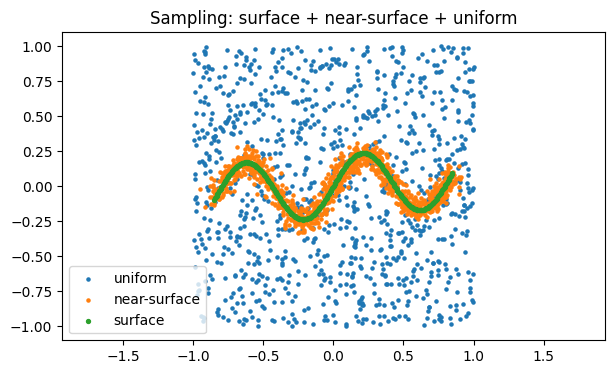

In [127]:
def make_open_curve_points(n=300):
    x = torch.linspace(-0.85, 0.85, n)
    y = 0.22 * torch.sin(2.4 * math.pi * x) + 0.08 * x
    return torch.stack([x, y], dim=-1)

curve_points = make_open_curve_points()

def make_queries_from_points_2d(points, n_surface=256, n_near=1024, n_uniform=1024, sigma=0.04):
    ids_s = torch.randint(len(points), (n_surface,))
    surface = points[ids_s]

    ids_n = torch.randint(len(points), (n_near,))
    near = points[ids_n] + sigma * torch.randn(n_near, 2)

    uniform = 2.0 * torch.rand(n_uniform, 2) - 1.0

    xyz = torch.cat([surface, near, uniform], dim=0)
    dist = torch.cdist(xyz, points)
    udf = dist.min(dim=1).values[:, None]
    return xyz, udf

xy_train, d_train = make_queries_from_points_2d(curve_points)

plt.figure(figsize=(7, 4))
plt.scatter(xy_train[-1024:, 0], xy_train[-1024:, 1], s=5, label="uniform")
plt.scatter(xy_train[256:256+1024, 0], xy_train[256:256+1024, 1], s=5, label="near-surface")
plt.scatter(curve_points[:, 0], curve_points[:, 1], s=8, label="surface")
plt.axis("equal")
plt.legend()
plt.title("Sampling: surface + near-surface + uniform")
plt.show()


## 4.2 A neural UDF of an open curve

An open curve has no globally consistent inside/outside, so no SDF is available — but the
UDF is perfectly well defined. This is the argument of the *"Why unsigned distance?"* slide.


In [128]:
open_udf_net = TinyMLP(2, hidden=64)
opt = torch.optim.Adam(open_udf_net.parameters(), lr=1e-3)

steps = 350 if FAST_MODE else 1000
history_open = []

for step in range(steps):
    xy, target = make_queries_from_points_2d(
        curve_points,
        n_surface=128,
        n_near=512,
        n_uniform=512,
        sigma=0.04,
    )
    pred = open_udf_net(xy)
    loss = F.l1_loss(pred, target)

    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()

    history_open.append(loss.item())

print("final loss:", history_open[-1])


final loss: 0.01965475082397461


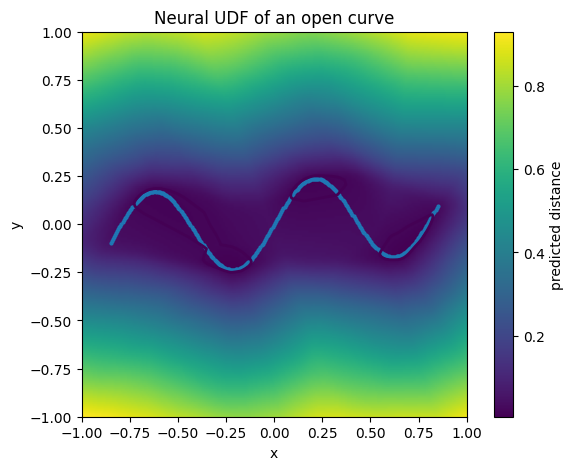

In [129]:
with torch.inference_mode():
    open_field = open_udf_net(grid2).reshape(R, R).numpy()

plt.figure(figsize=(7, 5))
plt.imshow(open_field, extent=[-1, 1, -1, 1], origin="lower")
plt.colorbar(label="predicted distance")
plt.scatter(curve_points[:, 0], curve_points[:, 1], s=4)
plt.contour(xx.numpy(), yy.numpy(), open_field, levels=[0.02], linewidths=2)
plt.title("Neural UDF of an open curve")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


> **↪ Back to the slides — slide 46:** *"What is a spatial gradient?"*  
> **Next notebook stop:** LAB 5 — Spatial gradients of a trained net (announced on slide 53)

---


---

# LAB 5 — Spatial gradients of a trained net

> **⟵ Coming from slides 46–52** &nbsp;·&nbsp; *"What is a spatial gradient?" → "From autograd to geometry"*  
> **Hand-off slide:** 53 — *"Now to the notebook"*

**Why we are here.** Slides 46–52 covered `torch.autograd.grad` with respect to the
*input*, and warned that a low distance error does not imply a usable gradient. Both
networks trained above are now available, so we can measure it.


## 5.1 Gradient norms near and far from the surface

For an exact distance field, $\lVert\nabla u\rVert=1$ wherever the field is
differentiable. Near the cusp the smooth surrogate has to flatten out, so the norm drops —
the effect predicted on slide 24.


In [130]:
probe = sample_square(4000, 2)
true_udf = analytic_udf_torch(probe).detach().squeeze(-1)

probe_grad = probe.detach().requires_grad_(True)
pred = udf_net_2d(probe_grad)
grad = torch.autograd.grad(
    pred, probe_grad,
    grad_outputs=torch.ones_like(pred)
)[0]
grad_norm = grad.norm(dim=-1).detach()

near = true_udf < 0.05
far = true_udf > 0.20

print("mean ||grad|| near surface:", grad_norm[near].mean().item())
print("mean ||grad|| farther away:", grad_norm[far].mean().item())
print("ideal differentiable distance-field value away from singularities: ~1")


mean ||grad|| near surface: 0.6726780533790588
mean ||grad|| farther away: 0.9746730327606201
ideal differentiable distance-field value away from singularities: ~1


## 5.2 The descent field $-\nabla_x f_\theta$

This is the quantity the projection step of LAB 6 will consume. If these arrows do not
point at the surface, no amount of correct *distance* will save the reconstruction — the
message of slide 51.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


mean ||grad|| near curve  : 0.25932765007019043
mean ||grad|| far from it : 0.9881973266601562


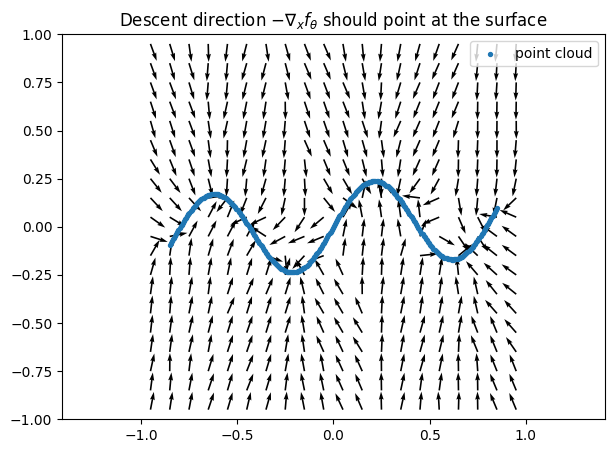

In [131]:
# Gradient field of the open-curve network: magnitude, then direction.
probe2 = (2.0 * torch.rand(3000, 2) - 1.0).requires_grad_(True)
pred2 = open_udf_net(probe2)
grad2 = torch.autograd.grad(pred2, probe2, grad_outputs=torch.ones_like(pred2))[0]

norm2 = grad2.norm(dim=-1).detach()
true_d2 = torch.cdist(probe2.detach(), curve_points).min(dim=1).values

print("mean ||grad|| near curve  :", norm2[true_d2 < 0.05].mean().item())
print("mean ||grad|| far from it :", norm2[true_d2 > 0.25].mean().item())

# Descent directions on a coarse grid.
g = torch.linspace(-0.95, 0.95, 20)
gy, gx = torch.meshgrid(g, g, indexing="ij")
q = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=-1).requires_grad_(True)
dq = open_udf_net(q)
gq = torch.autograd.grad(dq, q, grad_outputs=torch.ones_like(dq))[0]
gq = (gq / (gq.norm(dim=-1, keepdim=True) + 1e-8)).detach().numpy()
qn = q.detach().numpy()

plt.figure(figsize=(7, 5))
plt.quiver(qn[:, 0], qn[:, 1], -gq[:, 0], -gq[:, 1], scale=30, width=0.003)
plt.scatter(curve_points[:, 0], curve_points[:, 1], s=8, label="point cloud")
plt.axis("equal")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.legend()
plt.title(r"Descent direction $-\nabla_x f_\theta$ should point at the surface")
plt.show()


> **↪ Back to the slides — slide 54:** *"The intuition: moving a point onto the surface"*  
> **Next notebook stop:** LAB 6 — Gradient-based projection (announced on slide 60)

---


---

# LAB 6 — Gradient-based projection

> **⟵ Coming from slides 54–59** &nbsp;·&nbsp; *"The intuition: moving a point onto the surface" → "Operational summary"*  
> **Hand-off slide:** 60 — *"Now to the notebook"*

**Why we are here.** Slides 54–59 introduced the NDF projection update

$$x_{k+1}=x_k-f_\theta(x_k)\,\frac{\nabla_x f_\theta(x_k)}{\lVert\nabla_x f_\theta(x_k)\rVert_2+\varepsilon}.$$

We run it twice: first with the analytic field, where it must work, and then with the
network, where it may not.


## 6.1 Warm-up: projection driven by the analytic UDF

With the exact field the norm is $1$ and a single step already lands on the circle. This
is the behaviour the neural version is trying to imitate.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


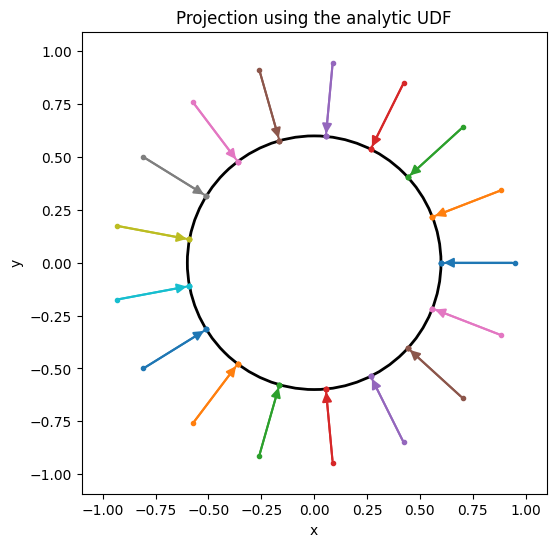

In [132]:
def project_with_field(x0, field_fn, steps=6, eps=1e-8):
    x = x0.detach().clone()
    trajectory = [x.clone()]
    for _ in range(steps):
        x = x.detach().requires_grad_(True)
        d = field_fn(x)
        g = torch.autograd.grad(
            d, x,
            grad_outputs=torch.ones_like(d),
            create_graph=False
        )[0]
        ghat = g / (g.norm(dim=-1, keepdim=True) + eps)
        x = (x - d * ghat).detach()
        trajectory.append(x.clone())
    return trajectory

angles = torch.linspace(0, 2 * math.pi, 18)[:-1]
r0 = 0.95
x0 = torch.stack([r0 * torch.cos(angles), r0 * torch.sin(angles)], dim=-1)

traj = project_with_field(x0, analytic_udf_torch, steps=4)

plt.figure(figsize=(6, 6))
circle = plt.Circle((0, 0), 0.6, fill=False, linewidth=2)
ax = plt.gca()
ax.add_patch(circle)

for i in range(x0.shape[0]):
    path = torch.stack([p[i] for p in traj]).numpy()
    line, = plt.plot(path[:, 0], path[:, 1], marker="o", markersize=3)
    for a, b in zip(path[:-1], path[1:]):
        if np.linalg.norm(b - a) > 1e-3:   # skip steps that no longer move
            ax.annotate("", xy=b, xytext=a,
                        arrowprops=dict(arrowstyle="-|>", color=line.get_color(), lw=1.5, mutation_scale=14))

plt.axis("equal")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.title("Projection using the analytic UDF")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## 6.2 The same loop, driven by the network

Now both the step length and the direction come from `open_udf_net`. Watch what happens
near the open ends of the curve, where the field is least reliable.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


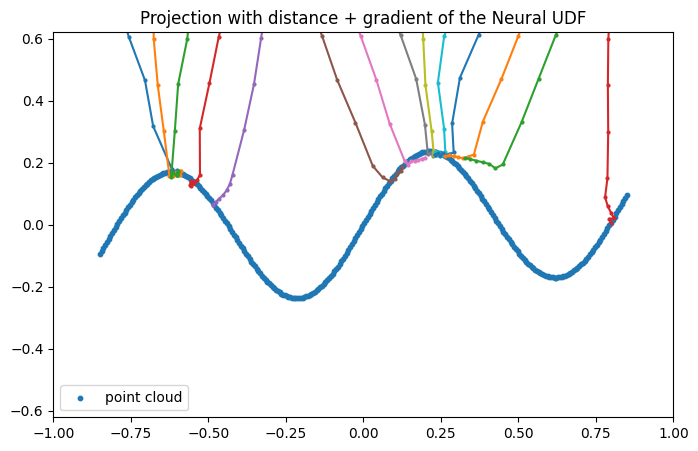

In [133]:
def project_with_neural_udf(model, x0, steps=8, max_step=0.15, eps=1e-8):
    x = x0.detach().clone()
    traj = [x.clone()]

    for _ in range(steps):
        x = x.detach().requires_grad_(True)
        d = model(x)
        g = torch.autograd.grad(
            d, x,
            grad_outputs=torch.ones_like(d),
            create_graph=False
        )[0]

        ghat = g / (g.norm(dim=-1, keepdim=True) + eps)

        # The canonical formula assumes a non-negative UDF. This baseline has a
        # linear output, so predictions can go slightly negative. We clamp the
        # step and use the predicted value as a signed correction towards zero:
        # d > 0 -> descend the field; d < 0 -> move the other way.
        step_len = d.clamp(min=-max_step, max=max_step)
        x = (x - step_len * ghat).detach()
        traj.append(x.clone())

    return traj

x0 = torch.stack([
    torch.linspace(-0.8, 0.8, 14),
    0.75 * torch.ones(14)
], dim=-1)

traj = project_with_neural_udf(open_udf_net, x0, steps=10)

plt.figure(figsize=(8, 5))
plt.scatter(curve_points[:, 0], curve_points[:, 1], s=10, label="point cloud")

for i in range(x0.shape[0]):
    path = torch.stack([p[i] for p in traj]).numpy()
    plt.plot(path[:, 0], path[:, 1], marker="o", markersize=2)

plt.axis("equal")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.title("Projection with distance + gradient of the Neural UDF")
plt.legend()
plt.show()


> **↪ Back to the slides — slide 61:** *"Motivation: implicit fields also contain high frequencies"*  
> **Next notebook stop:** LAB 7 — ReLU vs. SIREN (announced on slide 68)

---


---

# LAB 7 — ReLU vs. SIREN

> **⟵ Coming from slides 61–67** &nbsp;·&nbsp; *"Motivation: implicit fields also contain high frequencies" → "Main message"*  
> **Hand-off slide:** 68 — *"Now to the notebook"*

**Why we are here.** Slides 61–67 argued that the architecture decides which functions are
*easy* to learn, and that SIREN is three things at once: a periodic activation, a frequency
scale $\omega_0$ and a matching initialization. Here is the minimal implementation.


In [134]:
class SineLayer(nn.Module):
    def __init__(self, in_f, out_f, w0=30.0, is_first=False):
        super().__init__()
        self.in_f = in_f
        self.w0 = w0
        self.is_first = is_first
        self.linear = nn.Linear(in_f, out_f)
        self.reset_parameters()

    def reset_parameters(self):
        with torch.no_grad():
            if self.is_first:
                bound = 1.0 / self.in_f
            else:
                bound = math.sqrt(6.0 / self.in_f) / self.w0
            self.linear.weight.uniform_(-bound, bound)
            self.linear.bias.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.w0 * self.linear(x))

class TinySIREN(nn.Module):
    def __init__(self, in_dim=2, hidden=64, out_dim=1, w0=30.0):
        super().__init__()
        self.net = nn.Sequential(
            SineLayer(in_dim, hidden, w0=w0, is_first=True),
            SineLayer(hidden, hidden, w0=w0),
            SineLayer(hidden, hidden, w0=w0),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)

relu_model = TinyMLP(2, 64)
siren_model = TinySIREN(2, 64)

print("ReLU  parameters:", sum(p.numel() for p in relu_model.parameters()))
print("SIREN parameters:", sum(p.numel() for p in siren_model.parameters()))


ReLU  parameters: 8577
SIREN parameters: 8577


### 7.1 A quick head-to-head

Same UDF target, same budget, same optimizer — only the activation differs. Keep the step
count small during the talk; the point is the shape of the curves, not a benchmark.


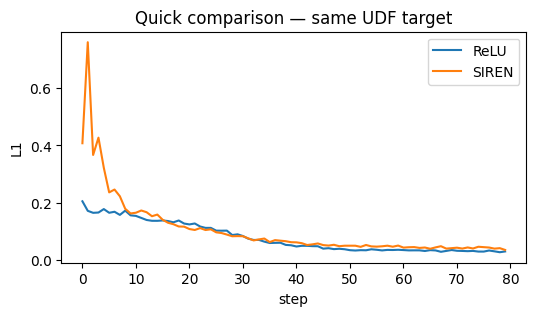

In [135]:
def quick_train(model, points, steps=120):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist = []
    for _ in range(steps):
        xy, target = make_queries_from_points_2d(
            points, n_surface=64, n_near=256, n_uniform=256, sigma=0.04
        )
        pred = model(xy)
        loss = F.l1_loss(pred, target)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        hist.append(loss.item())
    return hist

quick_steps = 80 if FAST_MODE else 250
hist_relu = quick_train(relu_model, curve_points, quick_steps)
hist_siren = quick_train(siren_model, curve_points, quick_steps)

plt.figure(figsize=(6, 3))
plt.plot(hist_relu, label="ReLU")
plt.plot(hist_siren, label="SIREN")
plt.xlabel("step")
plt.ylabel("L1")
plt.legend()
plt.title("Quick comparison — same UDF target")
plt.show()


### 7.2 A curve with high frequencies

The curve of LAB 4 is smooth, so both networks can fit it. Here we add a fast wiggle on
top of a slow wave, $y = 0.25\sin(1.2\pi x) + 0.07\sin(14\pi x)$, and train both networks
for the same number of steps on the same kind of samples (surface + near + uniform).

The only other difference is the learning rate. SIREN uses $10^{-4}$, the usual value for
it. With $10^{-3}$ its training becomes noisy and the comparison would be unfair.

**How to read the plot.** For every $x$ we take the $y$ where the network's field is
lowest, i.e. the bottom of its valley. That is the curve the network has learned, drawn on
top of the true curve (black).

- **ReLU** follows the slow wave but cuts through the fast wiggle: it misses the peaks and
  the troughs. This is the spectral bias of slide 61.
- **SIREN** reaches the peaks and troughs. The sine activations with $\omega_0$ make high
  frequencies easy to represent.
- **The losses end up almost the same.** Most samples are far from the curve, where both
  fields are fine, so the loss barely sees the difference. The geometry is where the
  architectures differ.

ReLU   mean |y_learned - y_true| = 0.0451
SIREN  mean |y_learned - y_true| = 0.0162


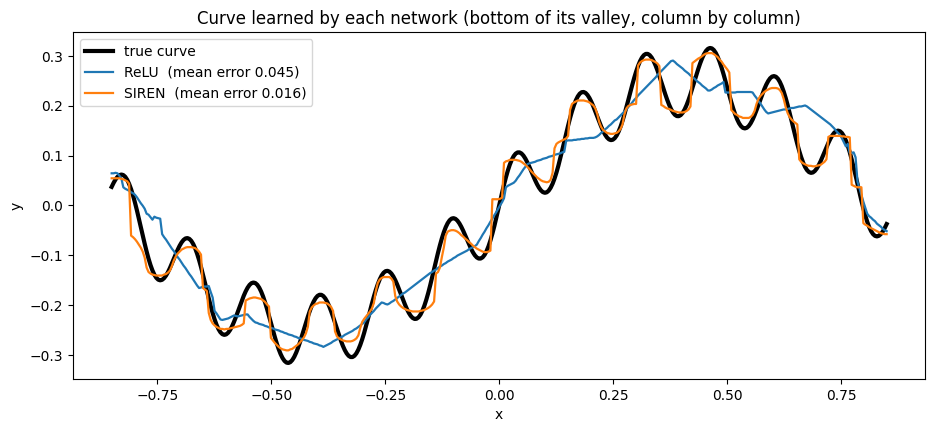

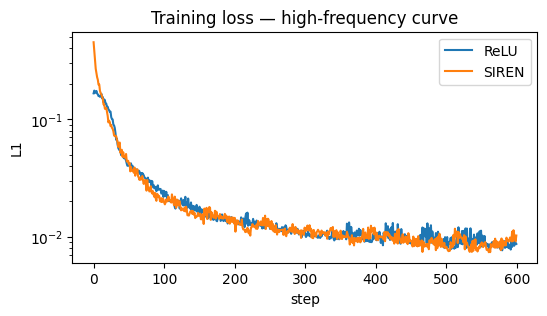

In [136]:
def make_hf_curve_points(n=2000, freq=14.0):
    # A slow wave plus a fast wiggle: 7 small oscillations per unit length.
    x = torch.linspace(-0.85, 0.85, n)
    y = 0.25 * torch.sin(1.2 * math.pi * x) + 0.07 * torch.sin(freq * math.pi * x)
    return torch.stack([x, y], dim=-1)

hf_points = make_hf_curve_points()

def train_hf(model, points, steps, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = []
    t0 = time.time()
    for _ in range(steps):
        xy, target = make_queries_from_points_2d(
            points, n_surface=128, n_near=512, n_uniform=512, sigma=0.02
        )
        loss = F.l1_loss(model(xy), target)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        hist.append(loss.item())
    return hist, time.time() - t0

hf_steps = 600 if FAST_MODE else 1500
relu_hf = TinyMLP(2, 64)
siren_hf = TinySIREN(2, 64)
hist_relu_hf, t_relu = train_hf(relu_hf, hf_points, hf_steps)
hist_siren_hf, t_siren = train_hf(siren_hf, hf_points, hf_steps, lr=1e-4)  # SIREN's usual lr

# For every x, the y where each network's field is lowest: the curve the network has learned.
xs = torch.linspace(-0.85, 0.85, 400)
ys = torch.linspace(-0.6, 0.6, 1200)
col_y, col_x = torch.meshgrid(ys, xs, indexing="ij")
columns = torch.stack([col_x.reshape(-1), col_y.reshape(-1)], dim=-1)
y_true = make_hf_curve_points(n=len(xs))[:, 1]

learned = {}
with torch.inference_mode():
    for name, net in [("ReLU", relu_hf), ("SIREN", siren_hf)]:
        field = net(columns).reshape(len(ys), len(xs))
        learned[name] = ys[field.argmin(dim=0)]

plt.figure(figsize=(11, 4.5))
plt.plot(xs, y_true, color="black", linewidth=3, label="true curve")
for name, color in [("ReLU", "tab:blue"), ("SIREN", "tab:orange")]:
    err = (learned[name] - y_true).abs().mean()
    print(f"{name:<5}  mean |y_learned - y_true| = {err:.4f}")
    plt.plot(xs, learned[name], color=color, linewidth=1.6, label=f"{name}  (mean error {err:.3f})")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Curve learned by each network (bottom of its valley, column by column)")
plt.legend(loc="upper left")
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(hist_relu_hf, label="ReLU")
plt.plot(hist_siren_hf, label="SIREN")
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("L1")
plt.legend()
plt.title("Training loss — high-frequency curve")
plt.show()

> **↪ Back to the slides — slide 69:** *"From the continuous field to a grid"*  
> **Next notebook stop:** LAB 8 — Marching Cubes: SDF vs. UDF (announced on slide 74)

---


---

# LAB 8 — Marching Cubes: SDF vs. UDF

> **⟵ Coming from slides 69–73** &nbsp;·&nbsp; *"From the continuous field to a grid" → "MeshUDF: recovering pseudo-signs from the gradients"*  
> **Hand-off slide:** 74 — *"Now to the notebook"*

**Why we are here.** Slides 69–73 claimed that Marching Cubes needs a sign change, that a
UDF never provides one, and that a positive level set gives an *offset* rather than the
surface. All three are one cell away from being demonstrated.


In [137]:
def make_grid3d(R=36, lo=-1.0, hi=1.0):
    a = np.linspace(lo, hi, R, dtype=np.float32)
    zz, yy, xx = np.meshgrid(a, a, a, indexing="ij")
    xyz = np.stack([xx, yy, zz], axis=-1)
    return a, xyz

R3 = 36 if FAST_MODE else 48
a3, xyz3 = make_grid3d(R3)

sdf3 = np.linalg.norm(xyz3, axis=-1) - 0.62
udf3 = np.abs(sdf3)

h = 2.0 / (R3 - 1)

verts, faces, normals, values = measure.marching_cubes(
    sdf3,
    level=0.0,
    spacing=(h, h, h),
)

# marching_cubes returns spatial indices starting at 0;
# we add the origin of the bounding box.
verts = verts + np.array([-1.0, -1.0, -1.0])

print("SDF  -> vertices:", len(verts), "| faces:", len(faces))
print("UDF min/max:", udf3.min(), udf3.max())

try:
    measure.marching_cubes(udf3, level=0.0, spacing=(h, h, h))
    print("The grid hit exactly zero by numerical coincidence.")
except ValueError as e:
    print("As expected, MC(level=0) on the UDF failed:")
    print(" ", e)


SDF  -> vertices: 2256 | faces: 4508
UDF min/max: 0.0025661588 1.1120508
As expected, MC(level=0) on the UDF failed:
  Surface level must be within volume data range.


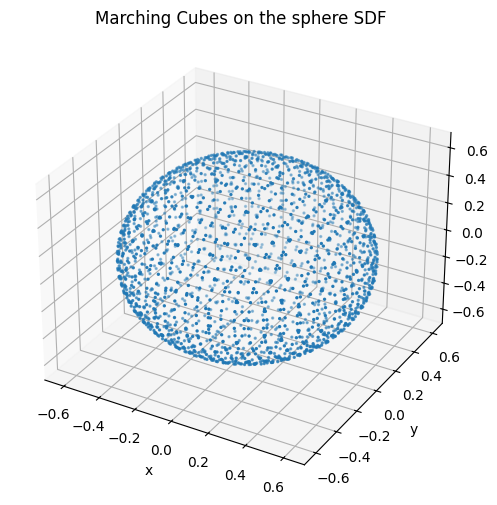

In [138]:
# Simple scatter of the vertices of the mesh extracted from the SDF.
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
idx = np.arange(len(verts))[::max(1, len(verts)//2500)]
ax.scatter(verts[idx, 0], verts[idx, 1], verts[idx, 2], s=2)
ax.set_title("Marching Cubes on the sphere SDF")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()


### Marching Cubes, one cell at a time

Before running it on a fine grid, we look at what Marching Cubes does **inside a single
cell**, on a deliberately coarse $4\times4\times4$ grid of the same sphere SDF:

1. **Classify the 8 corners** by sign: inside ($s<0$, blue) or outside ($s>0$).
2. **Find the crossed edges**: an edge whose two corners have opposite signs contains a
   zero. Its position is found by linear interpolation, $t = s_a/(s_a-s_b)$ (red).
3. **Connect the crossings into triangles.** The pattern of signs (one of $2^8=256$ cases)
   indexes a lookup table that says which triangles to build.

The edges use the classic numbering $0$–$11$. Then the cube **marches** through the grid: each
cell contributes its own triangles, and together they form the mesh. Cells without a sign
change contribute nothing. The triangles of each cell come from `measure.marching_cubes`
on that cell's $2\times2\times2$ block, so they are exactly what the full call produces.

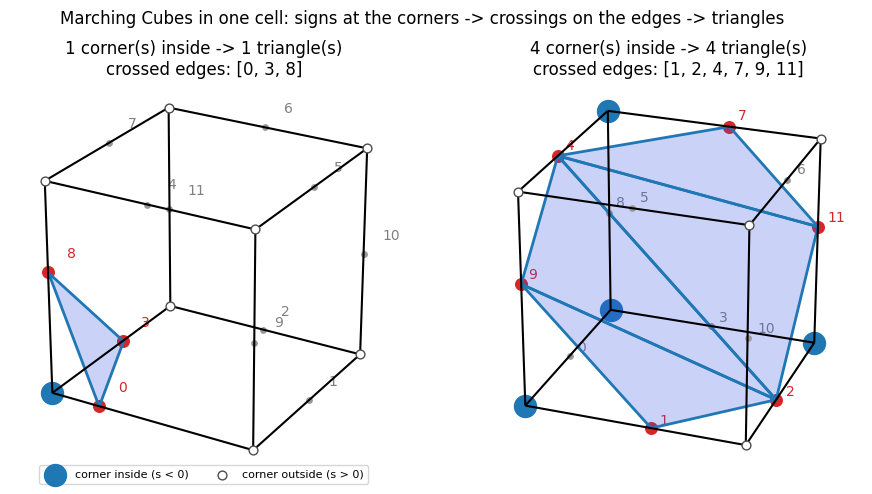

In [139]:
from matplotlib import animation
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection
from IPython.display import HTML

# A deliberately coarse grid (4 x 4 x 4 cells) of the same sphere SDF, indexed [x, y, z].
n_cells = 4
g = np.linspace(-1.0, 1.0, n_cells + 1)
hc = g[1] - g[0]
GX, GY, GZ = np.meshgrid(g, g, g, indexing="ij")
sdf_coarse = np.sqrt(GX**2 + GY**2 + GZ**2) - 0.62

# Cube corners and the 12 edges, in the classic numbering (Lorensen & Cline / Bourke).
CORNERS = np.array([[0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0],
                    [0, 0, 1], [1, 0, 1], [1, 1, 1], [0, 1, 1]])
EDGES = [(0, 1), (1, 2), (2, 3), (3, 0), (4, 5), (5, 6),
         (6, 7), (7, 4), (0, 4), (1, 5), (2, 6), (3, 7)]

def cell_triangles(i, j, k):
    """Triangles Marching Cubes generates inside cell (i, j, k): MC on its 2x2x2 block."""
    block = sdf_coarse[i:i + 2, j:j + 2, k:k + 2]
    if block.min() > 0 or block.max() < 0:
        return np.zeros((0, 3, 3))                 # no sign change: the cell is skipped
    v, f, _, _ = measure.marching_cubes(block, level=0.0, spacing=(hc, hc, hc))
    return (v + np.array([g[i], g[j], g[k]]))[f]

def cube_edges(origin, size):
    c = origin + size * CORNERS
    return [[c[a], c[b]] for a, b in EDGES]

def cube_faces(origin, size):
    c = origin + size * CORNERS
    return [c[[0, 1, 2, 3]], c[[4, 5, 6, 7]], c[[0, 1, 5, 4]],
            c[[2, 3, 7, 6]], c[[1, 2, 6, 5]], c[[0, 3, 7, 4]]]

# --- One cube, close up: two cells of the grid above --------------------------------
def draw_single_cell(ax, ci, cj, ck, azim=-60):
    origin = np.array([g[ci], g[cj], g[ck]])
    corner_pts = origin + hc * CORNERS
    corner_s = np.array([sdf_coarse[ci + a, cj + b, ck + c] for a, b, c in CORNERS])
    tris = cell_triangles(ci, cj, ck)

    ax.add_collection3d(Line3DCollection(cube_edges(origin, hc), colors="black", linewidths=1.5))
    crossed = []
    for e, (a, b) in enumerate(EDGES):
        pa, pb = corner_pts[a], corner_pts[b]
        sa, sb = corner_s[a], corner_s[b]
        if sa * sb < 0:                              # sign change: the surface crosses this edge
            t = sa / (sa - sb)                       # linear interpolation of the zero
            p = pa + t * (pb - pa)
            ax.scatter(*p, color="tab:red", s=70, depthshade=False)
            crossed.append(e)
        else:
            p = 0.5 * (pa + pb)
            ax.scatter(*p, color="0.6", s=15, depthshade=False)
        ax.text(*(p + 0.03), str(e), color="tab:red" if sa * sb < 0 else "0.5", fontsize=10)

    inside = corner_s < 0
    ax.scatter(*corner_pts[inside].T, color="tab:blue", s=250, depthshade=False, label="corner inside (s < 0)")
    ax.scatter(*corner_pts[~inside].T, facecolor="white", edgecolor="0.3", s=40, depthshade=False,
               label="corner outside (s > 0)")
    ax.add_collection3d(Poly3DCollection(tris, facecolors=(0.2, 0.3, 0.9, 0.25),
                                         edgecolors="tab:blue", linewidths=2))
    ax.set_box_aspect((1, 1, 1))
    ax.set_xlim(origin[0], origin[0] + hc)
    ax.set_ylim(origin[1], origin[1] + hc)
    ax.set_zlim(origin[2], origin[2] + hc)
    ax.view_init(elev=25, azim=azim)
    ax.set_axis_off()
    ax.set_title(f"{inside.sum()} corner(s) inside -> {len(tris)} triangle(s)\ncrossed edges: {crossed}")

fig = plt.figure(figsize=(11, 5.5))
# [0.5,1]x[0,0.5]x[0,0.5] and [0,0.5]^3; the second view faces its hexagon.
for n, (cell, azim) in enumerate([((3, 2, 2), -60), ((2, 2, 2), 20)]):
    draw_single_cell(fig.add_subplot(1, 2, n + 1, projection="3d"), *cell, azim=azim)
fig.axes[0].legend(loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=8)
fig.suptitle("Marching Cubes in one cell: signs at the corners -> crossings on the edges -> triangles")
plt.show()

In [140]:
# --- The cube marching through the grid ---------------------------------------------
cells = [(i, j, k) for k in range(n_cells) for j in range(n_cells) for i in range(n_cells)]
grid_lines = []
for a in g:
    for b in g:
        grid_lines += [[(g[0], a, b), (g[-1], a, b)], [(a, g[0], b), (a, g[-1], b)],
                       [(a, b, g[0]), (a, b, g[-1])]]

fig = plt.figure(figsize=(5, 5), dpi=65)
ax = fig.add_subplot(111, projection="3d")

def draw_cell(frame):
    ax.cla()
    ax.set_box_aspect((1, 1, 1))
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
    ax.view_init(elev=20, azim=-55)
    ax.set_axis_off()
    ax.add_collection3d(Line3DCollection(grid_lines, colors="tab:red", linewidths=0.6, alpha=0.6))

    visited = cells[: min(frame + 1, len(cells))]
    mesh = [cell_triangles(*c) for c in visited]
    mesh = np.concatenate(mesh) if mesh else np.zeros((0, 3, 3))
    if len(mesh):
        ax.add_collection3d(Poly3DCollection(mesh, facecolors=(0.2, 0.3, 0.9, 0.12),
                                             edgecolors="tab:blue", linewidths=1.2))
    if frame < len(cells):
        i, j, k = cells[frame]
        new = len(cell_triangles(i, j, k))
        ax.add_collection3d(Poly3DCollection(cube_faces(np.array([g[i], g[j], g[k]]), hc),
                                             facecolors=(0.2, 0.8, 0.2, 0.3), edgecolors="black",
                                             linewidths=1.5))
        ax.set_title(f"cell {frame + 1}/{len(cells)}: +{new} triangle(s) | mesh: {len(mesh)}")
    else:
        ax.set_title(f"done: {len(mesh)} triangles from {n_cells}^3 cells")

anim_cells = animation.FuncAnimation(fig, draw_cell, frames=len(cells) + 8, interval=250)
plt.close(fig)
HTML(anim_cells.to_jshtml())

### Watching Marching Cubes build the mesh

The same call, replayed slice by slice. A horizontal plane sweeps the grid from bottom to
top, coloured by the SDF (red inside, blue outside). The black curve is where the slice
crosses zero: that is exactly where Marching Cubes finds a sign change on the cell edges
and places triangles. Below the plane is the mesh extracted so far, i.e. Marching Cubes run
on the slices already visited.

Rendering takes about 15 s on CPU; use the player controls to pause or step through it.

In [141]:
from matplotlib import animation
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from IPython.display import HTML

# sdf3 is indexed [z, y, x]: sweeping axis 0 moves a horizontal plane upwards.
slice_step = 2 if FAST_MODE else 1
sweep = list(range(1, R3, slice_step)) + [R3 - 1]
hold_frames = 6
light_dir = np.array([-0.3, -0.6, 0.75]) / np.linalg.norm([-0.3, -0.6, 0.75])

def mesh_below(k):
    """Marching Cubes on the z-slices [0, k]: the part of the mesh extracted so far."""
    slab = sdf3[: k + 1]
    if slab.min() > 0 or slab.max() < 0:
        return None
    v, f, n, _ = measure.marching_cubes(slab, level=0.0, spacing=(h, h, h))
    v = v[:, ::-1] - 1.0                                  # (z, y, x) indices -> (x, y, z) coordinates
    n = n[:, ::-1][f].mean(axis=1)
    shade = np.abs(n @ light_dir) / (np.linalg.norm(n, axis=1) + 1e-9)
    colors = plt.cm.Purples(0.35 + 0.5 * shade)
    return v[f], colors

fig = plt.figure(figsize=(5, 5), dpi=80)
ax = fig.add_subplot(111, projection="3d", computed_zorder=False)
px, py = np.meshgrid(a3, a3)

def draw_frame(i):
    k = sweep[min(i, len(sweep) - 1)]
    done = i >= len(sweep)
    ax.cla()
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=25, azim=-60)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

    mesh = mesh_below(k)
    if mesh is not None:
        tris, colors = mesh
        ax.add_collection3d(Poly3DCollection(tris, facecolors=colors, edgecolors=colors,
                                             linewidths=0.2, zorder=1))
    if not done:
        z = a3[k]
        plane = plt.cm.RdBu(np.clip(0.5 + sdf3[k] / 1.2, 0, 1))   # red inside, blue outside
        plane[..., 3] = 0.5
        ax.plot_surface(px, py, np.full_like(px, z), facecolors=plane,
                        rstride=1, cstride=1, shade=False, linewidth=0, zorder=2)
        for c in measure.find_contours(sdf3[k], 0.0):             # where the slice crosses zero
            cx = np.interp(c[:, 1], np.arange(R3), a3)
            cy = np.interp(c[:, 0], np.arange(R3), a3)
            ax.plot(cx, cy, np.full_like(cx, z), color="black", linewidth=1.5, zorder=3)
        ax.set_title(f"Marching Cubes sweep: slice {k + 1}/{R3}")
    else:
        ax.set_title("Marching Cubes on the sphere SDF: full mesh")

anim = animation.FuncAnimation(fig, draw_frame, frames=len(sweep) + hold_frames, interval=120)
plt.close(fig)
HTML(anim.to_jshtml())

### 8.1 A positive level set is an offset, not the surface

With `level = ε > 0` Marching Cubes succeeds — but locally it extracts the two **offset**
sheets around the surface, not the surface itself. This is why UDF meshing needs the
pseudo-sign machinery of MeshUDF (slide 73).


In [142]:
eps_level = 0.08
v_off, f_off, _, _ = measure.marching_cubes(
    udf3,
    level=eps_level,
    spacing=(h, h, h),
)
v_off = v_off + np.array([-1.0, -1.0, -1.0])

print("UDF offset level =", eps_level)
print("vertices:", len(v_off), "| faces:", len(f_off))


UDF offset level = 0.08
vertices: 4464 | faces: 8920


> **↪ Back to the slides — slide 75:** *"Where do time and memory disappear?"*  
> **Next notebook stop:** LAB 9 — Where the CPU time goes (announced on slide 81)

---


---

# LAB 9 — Where the CPU time goes

> **⟵ Coming from slides 75–80** &nbsp;·&nbsp; *"Where do time and memory disappear?" → "Performance checklist for the notebook"*  
> **Hand-off slide:** 81 — *"Now to the notebook"*

**Why we are here.** Slides 75–80 warned that in a UDF pipeline the MLP is often *not* the
bottleneck: nearest-neighbour search, $R^3$ grid queries and an autograd graph nobody uses
usually are. Two measurements, both on the models already in memory.


## 9.1 Distance targets: `torch.cdist` vs. a KD-tree

`torch.cdist` materialises the full $B\times M$ matrix. It is perfect for a demo and a poor
idea at research scale — the caution on slide 76.


In [143]:
queries = 2.0 * torch.rand(20000, 2) - 1.0

t0 = time.time()
d_cdist = torch.cdist(queries, curve_points).min(dim=1).values
t_cdist = time.time() - t0

tree2d = cKDTree(curve_points.numpy())
t0 = time.time()
d_tree, _ = tree2d.query(queries.numpy(), k=1, workers=-1)
t_tree = time.time() - t0

print(f"queries: {len(queries)}   surface points: {len(curve_points)}")
print(f"torch.cdist : {t_cdist*1e3:8.1f} ms   (full {len(queries)} x {len(curve_points)} matrix)")
print(f"cKDTree     : {t_tree*1e3:8.1f} ms")
print("max abs difference:", float(np.abs(d_cdist.numpy() - d_tree).max()))


queries: 20000   surface points: 300
torch.cdist :     14.6 ms   (full 20000 x 300 matrix)
cKDTree     :      5.6 ms
max abs difference: 1.5192068830461106e-05


## 9.2 Grid inference: `inference_mode` and chunking

A plain forward pass builds an autograd graph we are never going to use. Chunking keeps
peak memory bounded when the grid does not fit comfortably — slides 78 and 79.


In [144]:
R_big = 600
lin_big = torch.linspace(-1.0, 1.0, R_big)
by, bx = torch.meshgrid(lin_big, lin_big, indexing="ij")
grid_big = torch.stack([bx.reshape(-1), by.reshape(-1)], dim=-1)
print("grid queries:", grid_big.shape[0])

t0 = time.time()
out_plain = open_udf_net(grid_big)
t_plain = time.time() - t0

t0 = time.time()
with torch.inference_mode():
    out_fast = open_udf_net(grid_big)
t_infer = time.time() - t0

t0 = time.time()
chunks = []
with torch.inference_mode():
    for q in grid_big.split(65536):
        chunks.append(open_udf_net(q))
out_chunked = torch.cat(chunks, dim=0)
t_chunk = time.time() - t0

print(f"plain forward           : {t_plain*1e3:8.1f} ms")
print(f"inference_mode          : {t_infer*1e3:8.1f} ms")
print(f"inference_mode + chunks : {t_chunk*1e3:8.1f} ms")
print("max |plain - chunked|:", (out_plain.detach() - out_chunked).abs().max().item())


grid queries: 360000
plain forward           :    232.1 ms
inference_mode          :    238.4 ms
inference_mode + chunks :    148.6 ms
max |plain - chunked|: 0.0


> **↪ Back to the slides — slide 82:** *"Neural UDF baseline from scratch: the full pipeline"*  
> **Next notebook stop:** LAB 10 — End-to-end Neural UDF in 3D (announced on slide 90)

---


---

# LAB 10 — End-to-end Neural UDF in 3D

> **⟵ Coming from slides 82–89** &nbsp;·&nbsp; *"Neural UDF baseline from scratch: the full pipeline" → "End-to-end baseline: what should work before moving on"*  
> **Hand-off slide:** 90 — *"Now to the notebook"*

**Why we are here.** This is Steps A–F of slides 83–88, end to end, in 3D, on CPU. The
target is an **open** wavy patch

$$z=0.18\sin(\pi x)\cos(\pi y),\qquad x,y\in[-0.8,0.8],$$

so there is no inside/outside to fall back on.

**pipeline:** point cloud → queries → UDF targets → MLP → training → gradients → projection


## Step A — geometric supervision &nbsp;·&nbsp; *slide 83*

Surface, near-surface and uniform queries, with nearest-point targets from a KD-tree.
`cKDTree` is far cheaper on CPU than rebuilding the full `B × M` matrix with `torch.cdist`,
as LAB 9 measured.


In [145]:
def make_wavy_patch(nx=28, ny=28):
    xs = np.linspace(-0.8, 0.8, nx, dtype=np.float32)
    ys = np.linspace(-0.8, 0.8, ny, dtype=np.float32)
    yy, xx = np.meshgrid(ys, xs, indexing="ij")
    zz = 0.18 * np.sin(np.pi * xx) * np.cos(np.pi * yy)
    pts = np.stack([xx, yy, zz], axis=-1).reshape(-1, 3)
    return pts.astype(np.float32)

surface_np = make_wavy_patch(28, 28)
surface = torch.from_numpy(surface_np)

import plotly.graph_objects as go

fig = go.Figure(go.Scatter3d(
    x=surface_np[:, 0], y=surface_np[:, 1], z=surface_np[:, 2],
    mode="markers",
    marker=dict(size=2.5, color=surface_np[:, 2], colorscale="Viridis",
                colorbar=dict(title="z", thickness=12)),
    hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>z=%{z:.2f}<extra></extra>",
))
fig.update_layout(
    title="Point cloud of the 3D open surface (drag to rotate, scroll to zoom)",
    width=700, height=600,
    margin=dict(l=0, r=0, t=40, b=0),
    scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data"),
)
fig.show()

In [146]:
def build_udf_dataset_3d(surface_np, n_surface=2500, n_near=9000, n_uniform=9000, sigma=0.045):
    rng = np.random.default_rng(SEED)

    ids_s = rng.integers(0, len(surface_np), size=n_surface)
    surf = surface_np[ids_s]

    ids_n = rng.integers(0, len(surface_np), size=n_near)
    near = surface_np[ids_n] + rng.normal(0.0, sigma, size=(n_near, 3)).astype(np.float32)

    uniform = rng.uniform(-1.0, 1.0, size=(n_uniform, 3)).astype(np.float32)

    xyz = np.concatenate([surf, near, uniform], axis=0).astype(np.float32)

    tree = cKDTree(surface_np)
    dist, _ = tree.query(xyz, k=1, workers=-1)
    udf = dist.astype(np.float32)[:, None]

    order = rng.permutation(len(xyz))
    return torch.from_numpy(xyz[order]), torch.from_numpy(udf[order])

xyz_all, udf_all = build_udf_dataset_3d(surface_np)

n_val = 2500
xyz_train, xyz_val = xyz_all[:-n_val], xyz_all[-n_val:]
udf_train, udf_val = udf_all[:-n_val], udf_all[-n_val:]

print("train:", xyz_train.shape, udf_train.shape)
print("val  :", xyz_val.shape, udf_val.shape)
print("target min/mean/max:",
      udf_train.min().item(),
      udf_train.mean().item(),
      udf_train.max().item())


train: torch.Size([18000, 3]) torch.Size([18000, 1])
val  : torch.Size([2500, 3]) torch.Size([2500, 1])
target min/mean/max: 0.0 0.23158089816570282 1.0994281768798828


## Step B — network, objective and optimizer &nbsp;·&nbsp; *slide 84*

The output stays **linear**: this is a distance surrogate, not a strict UDF. A strict UDF
would need a non-negative parametrization, and the original NDF additionally conditions the
decoder on the observation $X$.


In [147]:
class NeuralUDF3D(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)

model3d = NeuralUDF3D(hidden=64).to(device)
opt3d = torch.optim.Adam(model3d.parameters(), lr=1e-3)

print(model3d)
print("parameters:", sum(p.numel() for p in model3d.parameters()))


NeuralUDF3D(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
parameters: 8641


## Step C — training loop &nbsp;·&nbsp; *slide 85*

Random mini-batches and L1. Uncomment the truncated variant to move towards the loss the
original NDF actually uses.


In [148]:
def train_udf_model(model, xyz, udf, xyz_val, udf_val, steps=500, batch_size=1024):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist = {"train": [], "val": []}

    n = len(xyz)
    t0 = time.time()

    for step in range(steps):
        ids = torch.randint(0, n, (batch_size,))
        xb = xyz[ids]
        yb = udf[ids]

        pred = model(xb)
        loss = F.l1_loss(pred, yb)

        # NDF-style truncated regression (slide reference: the truncated L1):
        # delta = 0.10
        # loss = F.l1_loss(pred.clamp(max=delta), yb.clamp(max=delta))

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if step % 25 == 0 or step == steps - 1:
            with torch.inference_mode():
                val_pred = model(xyz_val)
                val_loss = F.l1_loss(val_pred, udf_val).item()
            hist["train"].append((step, loss.item()))
            hist["val"].append((step, val_loss))

    elapsed = time.time() - t0
    return hist, elapsed

final_steps = 450 if FAST_MODE else 1200
hist3d, elapsed3d = train_udf_model(
    model3d,
    xyz_train,
    udf_train,
    xyz_val,
    udf_val,
    steps=final_steps,
    batch_size=1024,
)

print(f"time: {elapsed3d:.2f}s")
print("last val L1:", hist3d["val"][-1][1])


time: 0.98s
last val L1: 0.010149814188480377


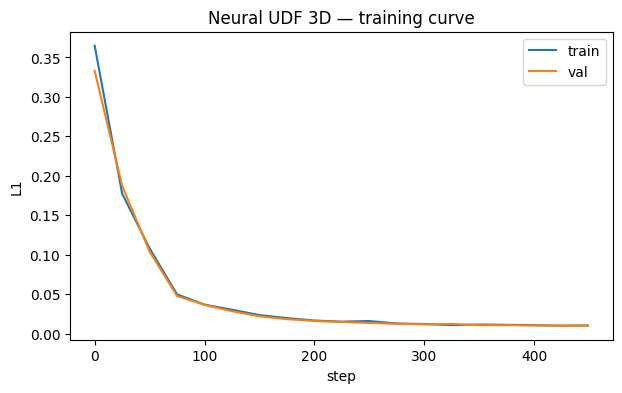

In [149]:
train_steps, train_losses = zip(*hist3d["train"])
val_steps, val_losses = zip(*hist3d["val"])

plt.figure(figsize=(7, 4))
plt.plot(train_steps, train_losses, label="train")
plt.plot(val_steps, val_losses, label="val")
plt.xlabel("step")
plt.ylabel("L1")
plt.legend()
plt.title("Neural UDF 3D — training curve")
plt.show()


## Step D — the field and its gradients &nbsp;·&nbsp; *slide 86*

Two outputs with different jobs: the values give *how far*, the gradients give *which way*.
Check both before trusting the projection.


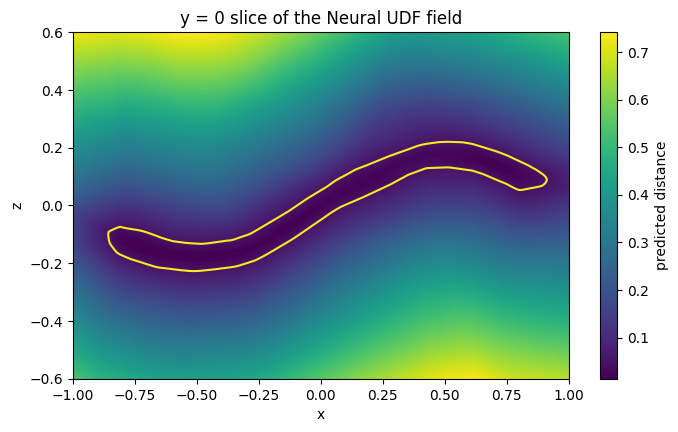

In [150]:
R_slice = 180
x = torch.linspace(-1, 1, R_slice)
z = torch.linspace(-0.6, 0.6, R_slice)
zz, xx_s = torch.meshgrid(z, x, indexing="ij")
yy_s = torch.zeros_like(xx_s)

slice_xyz = torch.stack(
    [xx_s.reshape(-1), yy_s.reshape(-1), zz.reshape(-1)],
    dim=-1
)

with torch.inference_mode():
    slice_pred = model3d(slice_xyz).reshape(R_slice, R_slice).numpy()

plt.figure(figsize=(8, 4.5))
plt.imshow(
    slice_pred,
    extent=[-1, 1, -0.6, 0.6],
    origin="lower",
    aspect="auto",
)
plt.colorbar(label="predicted distance")
plt.contour(
    xx_s.numpy(), zz.numpy(), slice_pred,
    levels=[0.02, 0.05],
    linewidths=1.5,
)
plt.title("y = 0 slice of the Neural UDF field")
plt.xlabel("x")
plt.ylabel("z")
plt.show()


In [151]:
sample_grad = xyz_val[:1200].detach().clone().requires_grad_(True)
pred_grad = model3d(sample_grad)

grad3d = torch.autograd.grad(
    pred_grad,
    sample_grad,
    grad_outputs=torch.ones_like(pred_grad),
    create_graph=False,
)[0]

norm3d = grad3d.norm(dim=-1).detach()

print("grad shape:", grad3d.shape)
print("min norm :", norm3d.min().item())
print("mean norm:", norm3d.mean().item())
print("max norm :", norm3d.max().item())


grad shape: torch.Size([1200, 3])
min norm : 0.02949637733399868
mean norm: 0.8184506893157959
max norm : 1.3706051111221313


## Step E — projecting a dense cloud &nbsp;·&nbsp; *slide 87*

Start above the patch and iterate the update. The result is the dense surface point cloud
that NDF triangulates downstream.


In [152]:
def project_points_3d(model, x0, steps=12, max_step=0.12, eps=1e-8):
    x = x0.detach().clone()

    for _ in range(steps):
        x = x.detach().requires_grad_(True)
        d = model(x)
        g = torch.autograd.grad(
            d, x,
            grad_outputs=torch.ones_like(d),
            create_graph=False,
        )[0]

        ghat = g / (g.norm(dim=-1, keepdim=True) + eps)
        # Linear-output baseline: the sign of the prediction is used only as a
        # numerical correction towards the zero level.
        step_len = d.clamp(min=-max_step, max=max_step)
        x = (x - step_len * ghat).detach()

    return x

rng = np.random.default_rng(123)
n_proj = 700
x0_np = np.column_stack([
    rng.uniform(-0.8, 0.8, n_proj),
    rng.uniform(-0.8, 0.8, n_proj),
    rng.uniform(0.35, 0.75, n_proj),
]).astype(np.float32)

x0_proj = torch.from_numpy(x0_np)
x_proj = project_points_3d(model3d, x0_proj, steps=14).numpy()

import plotly.graph_objects as go

fig = go.Figure([
    go.Scatter3d(x=surface_np[:, 0], y=surface_np[:, 1], z=surface_np[:, 2], mode="markers",
                 marker=dict(size=2, color="gray", opacity=0.6), name="target point cloud"),
    go.Scatter3d(x=x0_np[:, 0], y=x0_np[:, 1], z=x0_np[:, 2], mode="markers",
                 marker=dict(size=2, color="lightblue"), name="start (x0)", visible="legendonly"),
    go.Scatter3d(x=x_proj[:, 0], y=x_proj[:, 1], z=x_proj[:, 2], mode="markers",
                 marker=dict(size=2.5, color="crimson"), name="projected"),
])
fig.update_layout(
    title="Points projected by the Neural UDF (click the legend to show the start points)",
    width=800, height=600,
    margin=dict(l=0, r=0, t=40, b=0),
    scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data"),
    legend=dict(x=0, y=1),
)
fig.show()

## Step F — checkpoint &nbsp;·&nbsp; *slide 88*

For a research pipeline, also save the optimizer state, the step/epoch and the
configuration, as the slide lists.


In [153]:
checkpoint_path = Path("neural_udf_cpu_baseline.pt")

torch.save(
    {
        "model_state_dict": model3d.state_dict(),
        "seed": SEED,
        "fast_mode": FAST_MODE,
        "surface": "open wavy patch",
    },
    checkpoint_path,
)

print("checkpoint saved to:", checkpoint_path.resolve())


checkpoint saved to: /home/matheus/Documents/sibigrapi/neural_udf_cpu_baseline.pt


> **↪ Back to the slides — slide 91:** *"Block 1: what NDF demonstrated"*

---


# Guided exercises

1. **SDF → UDF (LAB 1).** Replace the circle with an ellipse and compare $s$ and $|s|$.
2. **The cusp (LAB 2).** Sample points ever closer to the zero level set and watch the
   one-sided derivatives.
3. **Sampling (LAB 4).** Change the near-surface / uniform ratio and look at local fidelity.
4. **Architecture (LAB 7).** Swap the final MLP for `TinySIREN` in LAB 10.
5. **Truncated loss (LAB 10, Step C).** Enable the commented-out
   $|\min(\hat d,\delta)-\min(d,\delta)|$ and compare.
6. **Marching Cubes (LAB 8).** Raise the grid resolution and watch the $R^3$ cost.
7. **Projection (LAB 6).** Compare iteration counts, `max_step` and initializations.
8. **Deliberate failure (LAB 4).** Train on `surface` samples only, with $d=0$ everywhere,
   and see the field collapse — the warning on slide 39.


# What this notebook implements — and what it does not

### Implemented

- analytic SDF/UDF fields;
- a coordinate MLP; neural SDF and neural UDF;
- surface / near-surface / uniform sampling;
- point-set distance targets;
- `torch.autograd.grad` with respect to the input;
- distance + gradient projection;
- a minimal SIREN;
- Marching Cubes on a signed field, and the `level=0` difficulty on a UDF;
- CPU cost measurements;
- end-to-end training of a 3D Neural UDF, plus a checkpoint.

### Deliberately simplified

The original NDF is not a single-shape MLP. It conditions the field on a sparse 3D
observation and uses a richer encoding/decoding architecture:

$$f_X(p)=(\Phi\circ\Psi_X)(p).$$

This notebook keeps the minimal implementation so that the mechanism stays visible, and
the slides state the difference explicitly wherever it matters.

> **↩ Back to the slides — slide 91:** *"Block 1: what NDF demonstrated"*, and on to Block 2.


---

# BONUS — A real scan: the Stanford Bunny

> applies it to real data, as a more concrete show-off than the synthetic curves and patches.

**The data.** The [Stanford 3D Scanning Repository](http://graphics.stanford.edu/data/3Dscanrep/)
distributes the raw range scans behind the famous bunny. We take **one** of them,
`bun000.ply`: about 40 000 points seen from a single scanner position. It is the front of
the bunny only, with no back and no bottom, so it is an **open surface**. There is no
inside/outside, so an SDF is not even defined, but a UDF is (the argument of LAB 4.2).

**The recipe** is LAB 10, scaled up:

| Step | From | What changes here |
|:--|:--|:--|
| nearest-point targets with a KD-tree | LAB 4, LAB 10 Step A | real points, two near-surface scales |
| coordinate MLP with linear output | LAB 3, LAB 10 Step B | wider (256) and one layer deeper |
| truncated L1 | LAB 10 Step C (exercise 5) | used for real, $\delta = 0.1$ |
| gradient projection | LAB 6, LAB 10 Step E | many more points, plus a densification pass |
| Marching Cubes at $\varepsilon > 0$ | LAB 8.1 | the offset mesh, rendered |

Budget: about 1–2 min on a laptop CPU with `FAST_MODE = True`. The first run downloads
4.9 MB and caches it in `data/`.

## B.1 Download one range scan

We download the archive once, extract only `bun000.ply` and read its vertices. The file is
plain-text PLY, so a few lines of NumPy are enough. The scan is then centred and scaled
into $[-0.9, 0.9]^3$, the box the LABs have been using. In `bun.conf`, `bun000` is the
reference frame, so it needs no alignment.

In [154]:
import tarfile
import urllib.request

import plotly.graph_objects as go

BUNNY_URL = "http://graphics.stanford.edu/pub/3Dscanrep/bunny.tar.gz"
data_dir = Path("data")
scan_path = data_dir / "bun000.ply"

if not scan_path.exists():
    data_dir.mkdir(exist_ok=True)
    archive = data_dir / "bunny.tar.gz"
    print("downloading", BUNNY_URL)
    urllib.request.urlretrieve(BUNNY_URL, archive)
    with tarfile.open(archive) as tar:
        member = tar.getmember("bunny/data/bun000.ply")
        member.name = scan_path.name                  # extract flat, into data/
        tar.extract(member, data_dir)
    archive.unlink()

def read_ply_vertices(path):
    """Vertices of an ASCII PLY file (x, y, z are the first three properties)."""
    with open(path) as fh:
        n_vertices, header_lines = None, 0
        for line in fh:
            header_lines += 1
            if line.startswith("element vertex"):
                n_vertices = int(line.split()[-1])
            if line.strip() == "end_header":
                break
    return np.loadtxt(path, skiprows=header_lines, max_rows=n_vertices,
                      usecols=(0, 1, 2), dtype=np.float32)

scan_raw = read_ply_vertices(scan_path)
center = 0.5 * (scan_raw.max(axis=0) + scan_raw.min(axis=0))
scale = 0.5 * (scan_raw.max(axis=0) - scan_raw.min(axis=0)).max()
bunny_pts = ((scan_raw - center) / scale * 0.9).astype(np.float32)
bunny_tree = cKDTree(bunny_pts)

print("points:", bunny_pts.shape, "| bounding box:", bunny_pts.min(axis=0).round(2), bunny_pts.max(axis=0).round(2))

def scene_layout(title):
    # The scan's "up" is +y; plotly's is +z, so we set the camera accordingly.
    return dict(
        title=title, width=800, height=600, margin=dict(l=0, r=0, t=40, b=0),
        scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data",
                   camera=dict(up=dict(x=0, y=1, z=0), eye=dict(x=0.3, y=0.4, z=2.0))),
        legend=dict(x=0, y=1),
    )

fig = go.Figure(go.Scatter3d(
    x=bunny_pts[:, 0], y=bunny_pts[:, 1], z=bunny_pts[:, 2], mode="markers",
    marker=dict(size=1.2, color=bunny_pts[:, 2], colorscale="Viridis"), name="scan",
))
fig.update_layout(**scene_layout("bun000.ply: one range scan, an open surface (rotate it: there is no back)"))
fig.show()

downloading http://graphics.stanford.edu/pub/3Dscanrep/bunny.tar.gz
points: (40256, 3) | bounding box: [-0.9  -0.88 -0.68] [0.9  0.88 0.68]


## B.2 Supervision: nearest-point distances at several scales

The same three regimes as LAB 4 and LAB 10 (surface, near-surface, uniform), with one
change: the near-surface samples use **two** noise scales. A tight one ($\sigma = 0.01$)
teaches the thin valley around the surface, where detail lives. A wide one ($\sigma = 0.05$)
fills the space between the surface and the uniform samples. Targets are distances to the
nearest scan point, from the KD-tree.

In [155]:
def build_bunny_dataset(points, tree, n_surface=20_000, n_near_tight=40_000,
                        n_near_wide=40_000, n_uniform=20_000, seed=SEED):
    rng = np.random.default_rng(seed)
    pick = lambda n: points[rng.integers(0, len(points), size=n)]
    xyz = np.concatenate([
        pick(n_surface),
        pick(n_near_tight) + rng.normal(0.0, 0.01, size=(n_near_tight, 3)),
        pick(n_near_wide) + rng.normal(0.0, 0.05, size=(n_near_wide, 3)),
        rng.uniform(-1.0, 1.0, size=(n_uniform, 3)),
    ]).astype(np.float32)
    dist, _ = tree.query(xyz, k=1, workers=-1)
    return torch.from_numpy(xyz), torch.from_numpy(dist.astype(np.float32))[:, None]

bunny_xyz, bunny_udf = build_bunny_dataset(bunny_pts, bunny_tree)
print("queries:", tuple(bunny_xyz.shape),
      f"| target min/mean/max: {bunny_udf.min():.3f} / {bunny_udf.mean():.3f} / {bunny_udf.max():.3f}")

queries: (120000, 3) | target min/mean/max: 0.000 / 0.089 / 1.292


## B.3 A bigger MLP and the truncated L1

The architecture is LAB 10's `NeuralUDF3D` pattern (ReLU layers, **linear** output), made
wider (256) and one layer deeper. The loss is the truncated L1 of NDF,
$|\min(\hat d,\delta)-\min(d,\delta)|$ with $\delta=0.1$. Far from the scan the network only
has to say "at least $\delta$", so its capacity goes to the region near the surface. A cosine
learning-rate schedule lets the last steps settle.

Why not SIREN (LAB 7)? We tried it: with the truncated loss and these settings its
training did not converge. It needs its own tuning of $\omega_0$ and the learning rate,
which is left as an exercise below.

parameters: 198657
step     0 | truncated L1 0.0621 |   0.1s
step   250 | truncated L1 0.0079 |  11.3s
step   500 | truncated L1 0.0047 |  22.5s
step   750 | truncated L1 0.0040 |  37.8s
step   999 | truncated L1 0.0037 |  48.0s


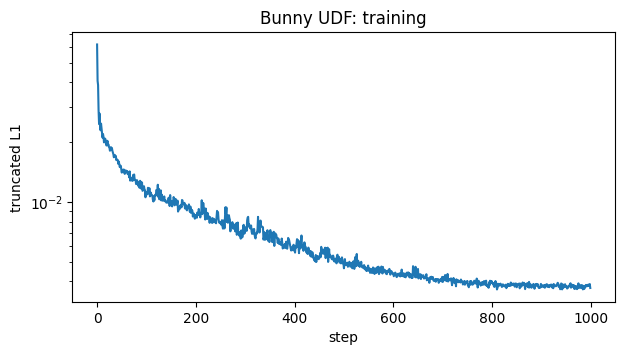

In [156]:
class BunnyUDF(nn.Module):
    def __init__(self, hidden=256, depth=4):
        super().__init__()
        layers = [nn.Linear(3, hidden), nn.ReLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        layers += [nn.Linear(hidden, 1)]                  # linear output, as in LAB 10
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def train_bunny(model, xyz, udf, steps, batch_size=4096, lr=1e-3, delta=0.1):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, steps)
    hist = []
    t0 = time.time()
    for step in range(steps):
        ids = torch.randint(0, len(xyz), (batch_size,))
        pred = model(xyz[ids])
        loss = F.l1_loss(pred.clamp(max=delta), udf[ids].clamp(max=delta))   # truncated L1
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        sched.step()
        hist.append(loss.item())
        if step % 250 == 0 or step == steps - 1:
            print(f"step {step:5d} | truncated L1 {loss.item():.4f} | {time.time() - t0:5.1f}s")
    return hist

bunny_model = BunnyUDF().to(device)
print("parameters:", sum(p.numel() for p in bunny_model.parameters()))

bunny_steps = 1000 if FAST_MODE else 3000
hist_bunny = train_bunny(bunny_model, bunny_xyz, bunny_udf, bunny_steps)

plt.figure(figsize=(7, 3.5))
plt.plot(hist_bunny)
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("truncated L1")
plt.title("Bunny UDF: training")
plt.show()

## B.4 Dense reconstruction by gradient projection

This is NDF's surface extraction, with `project_with_field` from LAB 6:

1. **Project** many points drawn uniformly in the box, $x \leftarrow x - f_\theta(x)\,\hat\nabla f_\theta(x)$.
2. **Filter**: keep only the points where the network now predicts a small distance. Points
   that got stuck (the wrong-direction gradients of LAB 3.4) are dropped here.
3. **Densify**: jitter the kept points slightly, project again and filter again.

We measure the result against the scan in both directions, with KD-trees. *Accuracy* is how
far the reconstructed points are from the scan. *Completeness* is how far the scan points
are from the reconstruction; it goes up where parts are missing.

In [157]:
def udf_field(x):
    return bunny_model(x)

rng_rec = np.random.default_rng(SEED)
n_dense = 30_000

t0 = time.time()
x_start = torch.from_numpy(rng_rec.uniform(-1.0, 1.0, size=(4 * n_dense, 3)).astype(np.float32))
x_first = project_with_field(x_start, udf_field, steps=8)[-1]
with torch.inference_mode():
    kept = x_first[udf_field(x_first).squeeze(-1) < 0.01]

x_jitter = kept[torch.randint(0, len(kept), (n_dense,))] + 0.02 * torch.randn(n_dense, 3)
x_dense = project_with_field(x_jitter, udf_field, steps=8)[-1]
with torch.inference_mode():
    bunny_rec = x_dense[udf_field(x_dense).squeeze(-1) < 0.005].numpy()
print(f"projection: {time.time() - t0:.1f}s | kept {len(kept)} of {len(x_start)} after pass 1, "
      f"{len(bunny_rec)} of {n_dense} after pass 2")

accuracy = bunny_tree.query(bunny_rec)[0]
completeness = cKDTree(bunny_rec).query(bunny_pts)[0]
print(f"accuracy     (reconstruction -> scan): mean {accuracy.mean():.4f}   95% {np.percentile(accuracy, 95):.4f}")
print(f"completeness (scan -> reconstruction): mean {completeness.mean():.4f}   95% {np.percentile(completeness, 95):.4f}")
print("for scale: the bunny is 1.8 wide; the median spacing between scan points is",
      f"{np.median(bunny_tree.query(bunny_pts, k=2)[0][:, 1]):.4f}")

fig = go.Figure([
    go.Scatter3d(x=bunny_pts[:, 0], y=bunny_pts[:, 1], z=bunny_pts[:, 2], mode="markers",
                 marker=dict(size=1.0, color="gray", opacity=0.5), name="scan (target)",
                 visible="legendonly"),
    go.Scatter3d(x=bunny_rec[:, 0], y=bunny_rec[:, 1], z=bunny_rec[:, 2], mode="markers",
                 marker=dict(size=1.2, color=bunny_rec[:, 2], colorscale="Viridis"),
                 name="reconstruction (projected)"),
])
fig.update_layout(**scene_layout("Points projected onto the Neural UDF (toggle the scan in the legend)"))
fig.show()

projection: 12.4s | kept 115311 of 120000 after pass 1, 24052 of 30000 after pass 2
accuracy     (reconstruction -> scan): mean 0.0074   95% 0.0195
completeness (scan -> reconstruction): mean 0.0124   95% 0.0378
for scale: the bunny is 1.8 wide; the median spacing between scan points is 0.0060


## B.5 A mesh from the UDF: the ε-offset

As LAB 8 showed, Marching Cubes cannot extract the zero level of a UDF: there is no sign
change. At a small level $\varepsilon > 0$ it succeeds, but it returns the **offset**
surface: a thin closed shell at distance $\varepsilon$ around the scan, with one sheet on
each side (LAB 8.1). It is a thickened bunny, not the scan itself, and it is still a useful
and honest preview. Recovering the actual open surface needs pseudo-signs from the
gradients, as MeshUDF does (slide 73).

In [158]:
R_mesh = 96 if FAST_MODE else 160
eps_mesh = 0.015
lin_m = np.linspace(-1.0, 1.0, R_mesh, dtype=np.float32)
grid_m = np.stack(np.meshgrid(lin_m, lin_m, lin_m, indexing="ij"), axis=-1).reshape(-1, 3)

t0 = time.time()
with torch.inference_mode():
    field_m = torch.cat([bunny_model(torch.from_numpy(chunk))
                         for chunk in np.array_split(grid_m, 16)]).reshape(R_mesh, R_mesh, R_mesh).numpy()
h_m = lin_m[1] - lin_m[0]
v_mesh, f_mesh, _, _ = measure.marching_cubes(field_m, level=eps_mesh, spacing=(h_m, h_m, h_m))
v_mesh -= 1.0
print(f"grid {R_mesh}^3 + Marching Cubes: {time.time() - t0:.1f}s | "
      f"{len(v_mesh)} vertices, {len(f_mesh)} triangles at level eps = {eps_mesh}")

fig = go.Figure(go.Mesh3d(
    x=v_mesh[:, 0], y=v_mesh[:, 1], z=v_mesh[:, 2],
    i=f_mesh[:, 0], j=f_mesh[:, 1], k=f_mesh[:, 2],
    color="mediumpurple", flatshading=False,
    lighting=dict(ambient=0.35, diffuse=0.8, specular=0.3, roughness=0.6),
    lightposition=dict(x=100, y=200, z=300), name=f"offset mesh (eps = {eps_mesh})",
))
fig.update_layout(**scene_layout(f"Marching Cubes at level eps = {eps_mesh}: the offset shell of the scan"))
fig.show()

grid 96^3 + Marching Cubes: 4.1s | 21930 vertices, 43860 triangles at level eps = 0.015


### Things to try

1. **Another view.** Swap `bun000.ply` for `bun045.ply` or `bun090.ply` from the same
   archive (their poses are in `bun.conf`), or merge several views.
2. **The loss.** Replace the truncated L1 with the plain L1 of LAB 10 and compare the
   accuracy numbers.
3. **Sampling.** Drop the tight near-surface scale ($\sigma = 0.01$) and watch the ears.
4. **SIREN.** Plug `TinySIREN` from LAB 7 in, widened to 256, and tune $\omega_0$ and the
   learning rate until it trains.
5. **The offset.** Lower `eps_mesh`: at some point the shell tears, where the network's
   minimum is above $\varepsilon$.